# Berlin Airbnb Hybrid Recommendation System: Marketplace Intelligence, Geospatial Analysis, and Personalized Listing Discovery

This project is an end-to-end recommendation and discovery analysis built using Airbnb listing and review data from Berlin.

The main goal is to understand how listing attributes, geographic context, pricing structure, and guest behavior can be combined to support a more personalized accommodation discovery experience. Rather than treating recommendations purely as a machine learning problem, the notebook approaches recommendation systems as an interpretable product and marketplace analysis problem.

The analysis combines exploratory analytics, behavioral signals, textual review information, and similarity-based recommendation logic to investigate how different data sources contribute to listing relevance and traveler discovery patterns.

The project is structured around the kinds of questions a marketplace platform, search-ranking team, or product analyst would need to answer in order to improve recommendation quality, traveler personalization, and listing visibility.

# Executive Summary

This project investigates how listing characteristics, geographic structure, pricing patterns, and guest interactions influence accommodation discovery in Berlin’s Airbnb marketplace.

Using listing metadata, review behavior, location signals, and text-based information, the analysis builds a hybrid recommendation framework designed to simulate how different recommendation signals can contribute to personalized listing discovery.

The project focuses not only on recommendation generation, but also on understanding which marketplace signals consistently contribute to perceived listing similarity, traveler relevance, and recommendation diversity.


### Main Findings

- Geographic proximity and neighborhood structure strongly influence listing similarity and recommendation clustering.
- Price range, room type, availability, and review volume create distinct marketplace segments with different recommendation dynamics.
- Textual review signals provide useful contextual information, although review sparsity limits their reliability for some listings.
- Behavioral interaction proxies help simulate collaborative filtering logic, but the dataset does not contain true booking or clickstream behavior.
- Hybrid recommendation logic produces more balanced recommendations than isolated content-based similarity alone.
- Recommendation quality depends heavily on feature engineering choices, marketplace sparsity, and the balance between popularity and personalization signals.

Overall, the results suggest that effective accommodation discovery depends on combining structured listing attributes, geographic context, and behavioral signals rather than relying on a single recommendation strategy.

# 1. Business Understanding

This project investigates how recommendation-oriented marketplace signals influence accommodation discovery behavior in Berlin's Airbnb ecosystem.

The analysis combines exploratory marketplace analytics with interpretable recommendation logic to evaluate not only how listings can be matched, but also which operational and behavioral signals contribute most to recommendation relevance.

### Core business questions

- Which listing attributes contribute most to perceived similarity between accommodations?
- How strongly does geographic context influence recommendation quality?
- Can textual review signals improve listing relevance beyond structured metadata alone?
- How much additional value do behavioral interaction proxies add relative to content-only recommendations?
- Do hybrid recommendation approaches create more balanced and diverse recommendations than isolated methods?

### Analytical objectives

- **Marketplace analysis:** understand pricing structure, geographic concentration, listing distribution, and review behavior.
- **Recommendation modeling:** build interpretable content-based, behavioral, and hybrid recommendation logic.
- **Behavioral interpretation:** evaluate how different recommendation signals influence listing similarity and recommendation diversity.
- **Product reasoning:** simulate how recommendation systems can support traveler discovery and marketplace exploration.

Throughout the notebook, the focus remains on transparent reasoning, interpretable recommendation logic, and business-oriented analysis rather than unnecessary modeling complexity or unrealistic production-level claims.

# 2. Environment Setup

This section initializes the analytical environment used throughout the notebook.

The setup is divided into focused blocks: core libraries, optional dependencies, project paths, visualization standards, compatibility settings, and reusable helper functions. This keeps the notebook easier to audit and prevents the technical setup from interrupting the analytical narrative.

## 2.1 Core Libraries and Global Settings

This section loads the core libraries used throughout the notebook and defines the global random seed for reproducibility.

The imports cover the main analytical needs of the project: data manipulation, geospatial analysis, interactive mapping, visualization, text processing, similarity-based recommendation logic, sparse matrices, and dimensionality reduction.

In [1]:
from pathlib import Path
import re
import ast
import json
import math
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

from scipy import sparse
from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer,
    ENGLISH_STOP_WORDS,
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

> Interpretation
> * The core environment is prepared for a recommendation-oriented analysis that combines structured listing data, text features, similarity models, and behavioral proxies.
> * Setting a fixed random seed improves reproducibility for later modeling steps, especially when sampling, matrix decomposition, or similarity-based workflows are used.
> * This block is intentionally limited to essential imports and global settings, keeping the technical setup cleaner and easier to audit.

## 2.3 Project Paths and Display Formatting

This section defines the local project structure used throughout the notebook, including directories for raw data, generated visualizations, and exported outputs.

It also standardizes dataframe display formatting to keep tables and numerical outputs more readable during exploratory analysis and recommendation evaluation.

In [2]:
DATA_DIR = Path("DATA")
IMAGE_DIR = Path("images")
OUTPUT_DIR = Path("outputs")

IMAGE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

> Interpretation
> * The notebook uses a simple project structure to separate raw datasets, generated visualizations, and exported analytical outputs.
> * Standardized dataframe formatting improves readability during exploratory analysis and helps reduce unnecessary visual noise in large tabular outputs.
> * Organizing outputs consistently becomes increasingly important as the recommendation workflow grows more complex and generates multiple intermediate artifacts.

## 2.4 Visualization Standards

This section defines the visual configuration used throughout the notebook, including the project color palette, chart styling, typography, and layout defaults.

The goal is to keep visual outputs consistent across exploratory analysis, recommendation evaluation, and marketplace interpretation while reducing unnecessary chart noise.

In [3]:
PALETTE = {
    "ink": "#263238",
    "muted": "#6B7280",
    "blue": "#4C78A8",
    "teal": "#2A9D8F",
    "orange": "#F4A261",
    "red": "#E76F51",
    "green": "#59A14F",
    "purple": "#7E6AAD",
    "sand": "#E9C46A",
    "light": "#F5F7FA",
    "grid": "#E5E7EB",
}

sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "grid.alpha": 0.3,
    },
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.titlecolor": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "grid.color": PALETTE["grid"],
    "font.size": 10,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
})

> Interpretation
> * The notebook uses a consistent visual style to keep exploratory charts, maps, and recommendation diagnostics visually aligned.
> * The custom palette supports clear separation between price, quality, popularity, value, and geospatial signals.
> * Standardized chart formatting helps the notebook feel more like an analytical product report than a collection of disconnected plots.

## 2.5 Compatibility Settings

Some preprocessing components behave differently across scikit-learn versions, especially sparse encoding utilities used in recommendation pipelines.

This section creates lightweight compatibility logic to ensure the notebook remains reproducible across different local environments without changing the downstream recommendation workflow.

In [4]:
try:
    _ = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
    )

    OHE_KWARGS = {
        "handle_unknown": "ignore",
        "sparse_output": True,
    }

except TypeError:
    OHE_KWARGS = {
        "handle_unknown": "ignore",
        "sparse": True,
    }

> Interpretation
> * Recommendation pipelines frequently rely on sparse feature representations, especially when encoding categorical listing attributes and interaction signals.
> * Small compatibility differences between scikit-learn versions can break preprocessing steps if they are not handled explicitly.
> * This compatibility layer keeps the notebook more portable without introducing unnecessary complexity into the modeling workflow.

## 2.6 Reusable Helper Functions

This section defines reusable utility functions used throughout the notebook for formatting, visualization consistency, normalization, and safe numerical operations.

Centralizing these helpers helps reduce repetitive code while keeping later analytical sections cleaner and easier to interpret.

In [5]:
def money_fmt(x, pos=None):
    if pd.isna(x):
        return ""

    return f"€{x:,.0f}"


def pct_fmt(x, pos=None):
    if pd.isna(x):
        return ""

    return f"{x:.0%}"


def save_fig(filename):
    path = IMAGE_DIR / filename

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    return path


def add_chart_title(ax, title, subtitle=None):
    ax.set_title(
        title,
        loc="left",
        pad=18,
    )

    if subtitle:
        ax.text(
            0,
            1.02,
            subtitle,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            color=PALETTE["muted"],
            fontsize=10,
        )

    return ax


def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.55)

    return ax


def minmax(series):
    s = pd.to_numeric(
        series,
        errors="coerce",
    )

    if s.notna().sum() == 0:
        return pd.Series(
            np.zeros(len(s)),
            index=s.index,
        )

    lo, hi = s.min(), s.max()

    if math.isclose(lo, hi):
        return pd.Series(
            np.ones(len(s)) * 0.5,
            index=s.index,
        )

    return (s - lo) / (hi - lo)


def safe_divide(a, b, default=np.nan):
    a = pd.to_numeric(
        a,
        errors="coerce",
    )

    b = pd.to_numeric(
        b,
        errors="coerce",
    )

    out = a / b.replace(0, np.nan)

    return out.fillna(default)

> Interpretation
> * Reusable utility functions help standardize formatting, normalization, and chart presentation across the notebook.
> * Centralizing repetitive operations improves maintainability and reduces unnecessary duplication in later analytical sections.
> * These helpers support cleaner exploratory workflows while keeping the recommendation logic itself easier to read and interpret.

# 3. Recommendation Framing

Accommodation discovery is fundamentally a matching problem.

Travelers are not simply selecting a place to stay; they are simultaneously evaluating price range, neighborhood identity, property type, amenities, availability, and the experiences described by previous guests.

This becomes especially relevant in Berlin, where Airbnb listings vary substantially across neighborhoods, pricing tiers, and hosting styles. As a result, recommendation quality depends not only on listing similarity, but also on how different marketplace signals are combined and prioritized.

Rather than treating recommendations as a purely algorithmic problem, this project approaches recommendation systems as a marketplace and product discovery challenge.

The recommendation framework developed throughout the notebook combines multiple layers of information:

- structured listing attributes and amenities,
- geographic and neighborhood context,
- review behavior as an implicit interaction signal,
- textual review information from guest comments,
- hybrid ranking logic adapted to different traveler preferences.

The central product question guiding the analysis is:

> **How can a recommendation system help travelers discover more relevant Berlin listings faster and with less search friction?**

> Interpretation
> * Recommendation quality in marketplace platforms depends on combining multiple signals rather than relying on a single similarity metric.
> * Geographic structure, pricing segmentation, amenities, and review behavior all contribute differently to perceived listing relevance.
> * The project focuses on interpretable recommendation logic and marketplace reasoning rather than attempting to replicate Airbnb’s proprietary production systems.

# 4. Data Collection and Dataset Structure

This project uses public Airbnb marketplace data from the Inside Airbnb project, including listing metadata, guest reviews, calendar availability, and neighborhood reference information for Berlin.

Berlin provides a useful recommendation-analysis environment because the marketplace contains substantial variation across neighborhoods, pricing tiers, property types, hosting behavior, and review activity. These differences create a strong setting for studying listing similarity, marketplace segmentation, and recommendation dynamics.

The data collection process focuses on building a reproducible local workflow that keeps the notebook portable while preserving the flexibility needed for exploratory analytics and recommendation modeling.

## 4.1 File Resolution and Dataset Access

This section initializes the dataset loading workflow used throughout the notebook.

The recommendation pipeline depends on multiple Airbnb data sources, including listing metadata, guest reviews, availability information, and neighborhood references. As a result, the loading logic is designed to keep the analytical workflow consistent across different file export variations and compressed formats.

In [6]:
DATA_DIR = Path("DATA")

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "DATA/ folder was not found in the project root."
    )


EXPECTED_FILES = {
    "listings_detailed": "listings.csv.gz",
    "listings_summary": "listings.csv",
    "reviews_detailed": "reviews.csv.gz",
    "reviews_summary": "reviews.csv",
    "calendar": "calendar.csv.gz",
    "neighbourhoods": "neighbourhoods.csv",
    "geojson": "neighbourhoods.geojson",
}


def normalize_col_name(col):
    return (
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
    )


def header_columns(path):
    try:
        cols = pd.read_csv(
            path,
            nrows=0,
            compression="infer",
        ).columns

        return [
            normalize_col_name(c)
            for c in cols
        ]

    except Exception:
        return []


def read_csv_robust(
    path,
    usecols=None,
    **kwargs,
):
    return pd.read_csv(
        path,
        compression="infer",
        low_memory=False,
        usecols=usecols,
        **kwargs,
    )


def resolve_data_file(
    expected_name,
    alternatives=None,
):
    alternatives = alternatives or []

    candidates = [
        DATA_DIR / expected_name,
        *[
            DATA_DIR / alt
            for alt in alternatives
        ],
    ]

    existing = [
        p for p in candidates
        if p.exists()
    ]

    if not existing:
        raise FileNotFoundError(
            f"No matching file found for {expected_name}"
        )

    return existing[0]

> Interpretation
> * The recommendation workflow combines multiple Airbnb datasets because listing relevance depends on both structured marketplace attributes and behavioral signals.
> * Review data, availability information, and neighborhood context complement the listing metadata and help support richer recommendation analysis.
> * At this stage, the notebook is only validating dataset accessibility before moving into exploratory and recommendation-oriented analysis.

## 4.2 Dataset Loading

This section loads the main datasets used throughout the recommendation analysis.

The workflow combines detailed listing information, guest reviews, and neighborhood references to support both marketplace exploration and recommendation-oriented feature engineering.

In [7]:
LISTINGS_PATH = resolve_data_file(
    "listings.csv.gz",
    alternatives=[
        "listings.csv",
        "listings.csv.gz.csv",
        "listings.csv.csv",
    ],
)

REVIEWS_PATH = resolve_data_file(
    "reviews.csv.gz",
    alternatives=[
        "reviews.csv",
        "reviews.csv.gz.csv",
        "reviews.csv.csv",
    ],
)

CALENDAR_PATH = resolve_data_file(
    "calendar.csv.gz",
    alternatives=[
        "calendar.csv",
        "calendar.csv.gz.csv",
    ],
)

NEIGHBOURHOODS_PATH = resolve_data_file(
    "neighbourhoods.csv",
    alternatives=[
        "neighbourhoods.csv.csv",
    ],
)

GEOJSON_PATH = resolve_data_file(
    "neighbourhoods.geojson",
)

listings_raw = read_csv_robust(
    LISTINGS_PATH,
)

reviews_raw = read_csv_robust(
    REVIEWS_PATH,
    usecols=[
        "listing_id",
        "id",
        "date",
        "reviewer_id",
        "reviewer_name",
        "comments",
    ],
)

neighbourhoods_raw = read_csv_robust(
    NEIGHBOURHOODS_PATH,
)

> Interpretation
> * The analytical workflow combines listing metadata, guest reviews, and neighborhood references because recommendation quality depends on multiple marketplace signals rather than isolated listing attributes.
> * Review data introduces behavioral and textual context, while neighborhood information supports geographic interpretation and location-aware recommendation analysis.
> * The datasets are loaded separately at this stage so their structure and analytical roles remain easier to validate before feature engineering begins.

## 4.3 Dataset Overview

Before starting the exploratory analysis, it is important to validate the scale and structure of the main datasets used throughout the recommendation workflow.

This overview helps establish the analytical scope of the project by summarizing the size and dimensionality of the core Airbnb data sources.

In [8]:
dataset_overview = pd.DataFrame([
    {
        "dataset": "Detailed listings",
        "rows": len(listings_raw),
        "columns": listings_raw.shape[1],
    },
    {
        "dataset": "Detailed reviews",
        "rows": len(reviews_raw),
        "columns": reviews_raw.shape[1],
    },
    {
        "dataset": "Neighbourhood reference",
        "rows": len(neighbourhoods_raw),
        "columns": neighbourhoods_raw.shape[1],
    },
])

dataset_overview

,dataset,rows,columns
0,Detailed listings,14274,79
1,Detailed reviews,635471,6
2,Neighbourhood reference,139,2


> Interpretation
> * The project combines datasets with very different granularities, ranging from listing-level metadata to large-scale guest review activity.
> * The review dataset is substantially larger than the listing dataset, which creates opportunities for behavioral and textual analysis but also introduces sparsity and computational considerations for recommendation modeling.
> * At this stage, the objective is only to validate dataset scale and analytical coverage before moving into cleaning, feature engineering, and exploratory marketplace analysis.

## 4.4 Initial Data Inspection

Before cleaning and feature engineering, the main datasets are briefly inspected to validate their structure, column availability, and overall content quality.

This initial inspection helps identify which marketplace, geographic, and behavioral signals are available for the recommendation workflow.

In [9]:
display(
    Markdown("### Detailed Listings Sample")
)

display(
    listings_raw[
        [
            "id",
            "name",
            "neighbourhood_cleansed",
            "property_type",
            "room_type",
            "price",
            "review_scores_rating",
            "number_of_reviews",
        ]
    ].head(3)
)

display(
    Markdown("### Detailed Reviews Sample")
)

display(
    reviews_raw.head(3)
)

### Detailed Listings Sample

,id,name,neighbourhood_cleansed,property_type,room_type,price,review_scores_rating,number_of_reviews
0,3176,Fabulous Flat in great Location,Prenzlauer Berg Südwest,Entire rental unit,Entire home/apt,$105.00,4.630,150
1,9991,Geourgeous flat - outstanding views,Prenzlauer Berg Südwest,Entire rental unit,Entire home/apt,$135.00,5.000,7
2,14325,Studio Apartment in Prenzlauer Berg,Prenzlauer Berg Nordwest,Entire rental unit,Entire home/apt,$75.00,4.680,26


### Detailed Reviews Sample

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,3176,4283,2009-06-20,21475,Milind,"excellent stay, i would highly recommend it. a nice flat in a very nice area. Britta p..."
1,3176,134722,2010-11-07,263467,George,Britta's apartment in Berlin is in a great area. There are numerous fantastic Restaur...
2,3176,144064,2010-11-24,76726,Patricia,"Fantastic, large place in good location. Only a short tram ride to Alexanderplatz U-S ..."


> Interpretation
> * The listings dataset contains a rich combination of pricing, property structure, host information, availability metrics, and review quality indicators that can support multiple recommendation signals.
> * The reviews dataset introduces large-scale textual and behavioral information that can later be used for sentiment exploration, semantic similarity, and interaction-based recommendation proxies.
> * This inspection stage is intentionally lightweight and focused on structural validation rather than exploratory conclusions.

# 5. Data Cleaning and Feature Preparation

This section transforms the raw Airbnb tables into a cleaner analytical base for marketplace exploration and recommendation modeling.

The goal is not to make the data perfect. The goal is to make the key recommendation inputs defensible, consistent, and interpretable enough to support later ranking logic.

The cleaning process focuses on variables that are relevant to accommodation discovery, including price, location, amenities, room type, host signals, guest ratings, review activity, availability, and behavioral proxies.

## 5.1 Cleaning Helper Functions

This section defines reusable cleaning functions used to standardize columns, parse monetary values, convert boolean fields, extract amenities, calculate geographic distance, and preserve consistent listing identifiers.

Keeping these transformations centralized makes the cleaning workflow easier to audit and reduces repeated logic across later feature engineering steps.

In [10]:
def standardize_columns(df):
    out = df.copy()
    out.columns = [
        normalize_col_name(c)
        for c in out.columns
    ]
    return out


def clean_money(series):
    if series is None:
        return pd.Series(dtype="float")

    return pd.to_numeric(
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace("€", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
        .replace({
            "nan": np.nan,
            "None": np.nan,
            "": np.nan,
        }),
        errors="coerce",
    )


def parse_bool(series):
    if series is None:
        return pd.Series(dtype="float")

    return (
        series.astype(str)
        .str.lower()
        .map({
            "t": 1,
            "true": 1,
            "yes": 1,
            "y": 1,
            "1": 1,
            "f": 0,
            "false": 0,
            "no": 0,
            "n": 0,
            "0": 0,
        })
        .fillna(0)
        .astype(int)
    )


def parse_amenities(value):
    if pd.isna(value):
        return []

    if isinstance(value, list):
        return [
            str(x).strip().lower()
            for x in value
        ]

    text = str(value).strip()

    try:
        parsed = ast.literal_eval(text)

        if isinstance(parsed, list):
            return [
                str(x).strip().lower()
                for x in parsed
            ]

    except Exception:
        pass

    text = (
        text.replace("[", " ")
        .replace("]", " ")
        .replace('"', " ")
        .replace("'", " ")
    )

    return [
        x.strip().lower()
        for x in text.split(",")
        if x.strip()
    ]


def contains_any(text, keywords):
    text = str(text).lower()

    return int(
        any(k in text for k in keywords)
    )


def haversine_km(
    lat1,
    lon1,
    lat2=52.5200,
    lon2=13.4050,
):
    lat1 = np.radians(
        pd.to_numeric(lat1, errors="coerce")
    )
    lon1 = np.radians(
        pd.to_numeric(lon1, errors="coerce")
    )
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c


def first_existing(df, candidates, default=None):
    for c in candidates:
        if c in df.columns:
            return c

    return default


def require_listing_id(df):
    out = df.copy()

    if "listing_id" not in out.columns and "id" in out.columns:
        out = out.rename(
            columns={"id": "listing_id"}
        )

    return out

> Interpretation
> * The cleaning helpers prepare raw Airbnb fields for recommendation-oriented feature engineering without introducing analytical assumptions too early.
> * Price parsing, amenity extraction, boolean conversion, and distance calculation are necessary because recommendation inputs need to be comparable across listings.
> * The geographic distance feature is an engineered proxy based on distance from central Berlin, so it should be interpreted as contextual location information rather than a direct measure of traveler preference.

## 5.2 Listing Table Cleaning

This section cleans the detailed listings table and creates a reliable listing-level base for later marketplace analysis and recommendation modeling.

The cleaning process focuses on defensible transformations: valid prices, usable coordinates, standardized categorical fields, parsed amenities, host-quality signals, review-based indicators, and availability-related features.

In [11]:
listings = standardize_columns(listings_raw)
listings = require_listing_id(listings)

if "listing_id" not in listings.columns:
    raise ValueError(
        "The listings dataset must include either listing_id or id."
    )

initial_rows = len(listings)

### 5.2.1 Price and Location Validation

This step validates the two most important structural inputs for listing comparison: nightly price and geographic location.

Listings without usable prices or plausible coordinates are removed because they cannot support reliable marketplace analysis, geographic interpretation, or recommendation ranking. Extreme price values are also filtered using a percentile-based rule to reduce distortion while preserving the main Berlin Airbnb price range.

In [12]:
price_col = first_existing(
    listings,
    ["price", "adjusted_price"],
)

listings["price"] = (
    clean_money(listings[price_col])
    if price_col
    else np.nan
)

listings = listings[
    listings["price"].notna()
    & (listings["price"] > 0)
].copy()

low_price, high_price = listings["price"].quantile(
    [0.01, 0.99]
)

listings = listings[
    listings["price"].between(
        low_price,
        high_price,
    )
].copy()

for col in ["latitude", "longitude"]:
    if col not in listings.columns:
        listings[col] = np.nan

    listings[col] = pd.to_numeric(
        listings[col],
        errors="coerce",
    )

listings = listings[
    listings["latitude"].between(-90, 90)
    & listings["longitude"].between(-180, 180)
].copy()

> Interpretation
> * The listing table is filtered to retain only records with valid positive nightly prices and plausible geographic coordinates.
> * The 1st and 99th percentile price cutoffs reduce the influence of extreme values without assuming that all expensive listings are invalid.
> * This filtering improves comparability across listings, but it also means the analysis focuses on the central Airbnb marketplace rather than the most extreme budget or luxury cases.

### 5.2.2 Dates and Core Listing Fields

This step standardizes the listing fields that define each accommodation’s basic identity and marketplace context.

Date columns are converted into proper datetime formats, while essential text and categorical fields are validated to preserve listing names, descriptions, room types, and neighborhood information for later exploratory analysis and recommendation modeling.

In [13]:
date_columns = [
    "last_scraped",
    "host_since",
    "first_review",
    "last_review",
    "calendar_last_scraped",
]

for col in date_columns:
    if col in listings.columns:
        listings[col] = pd.to_datetime(
            listings[col],
            errors="coerce",
        )

default_text_fields = {
    "name": "Berlin Airbnb listing",
    "description": "",
    "neighborhood_overview": "",
    "room_type": "Unknown",
}

for col, default in default_text_fields.items():
    if col not in listings.columns:
        listings[col] = default

    listings[col] = (
        listings[col]
        .fillna(default)
        .astype(str)
    )

if "neighbourhood_cleansed" not in listings.columns:
    fallback_neighbourhood = first_existing(
        listings,
        [
            "neighbourhood",
            "neighborhood",
            "neighbourhood_group",
            "neighborhood_group",
        ],
    )

    listings["neighbourhood_cleansed"] = (
        listings[fallback_neighbourhood]
        if fallback_neighbourhood
        else "Unknown"
    )

if "neighbourhood_group_cleansed" not in listings.columns:
    fallback_group = first_existing(
        listings,
        [
            "neighbourhood_group",
            "neighborhood_group",
        ],
    )

    listings["neighbourhood_group_cleansed"] = (
        listings[fallback_group]
        if fallback_group
        else listings["neighbourhood_cleansed"]
    )

listings["neighbourhood_cleansed"] = (
    listings["neighbourhood_cleansed"]
    .fillna("Unknown")
    .astype(str)
)

listings["neighbourhood_group_cleansed"] = (
    listings["neighbourhood_group_cleansed"]
    .fillna("Unknown")
    .astype(str)
)

> Interpretation
> * Core text and categorical fields are standardized to preserve listing identity, neighborhood context, and room-type information for later similarity modeling.
> * Missing text values are treated as empty context rather than evidence of poor listing quality.
> * Neighborhood fields are preserved carefully because location is expected to be one of the most important recommendation signals.

### 5.2.3 Amenities and Listing Attributes

This step transforms raw amenity information into structured listing attributes that can be used in later similarity and recommendation logic.

Amenities are especially relevant for accommodation discovery because they describe practical stay conditions that are not fully captured by price, location, or room type alone. The goal is to convert this raw text field into interpretable signals such as workspace availability, kitchen access, laundry, parking, heating, elevator access, and connectivity.

In [14]:
if "amenities" not in listings.columns:
    listings["amenities"] = ""

listings["amenities_list"] = listings["amenities"].apply(
    parse_amenities
)

listings["amenities_text"] = listings["amenities_list"].apply(
    lambda x: " ".join(x)
)

listings["number_of_amenities"] = listings["amenities_list"].apply(
    len
)

amenity_keywords = {
    "has_wifi": ["wifi", "wi fi", "internet"],
    "has_kitchen": ["kitchen", "cooking"],
    "has_washer": ["washer", "washing machine", "laundry"],
    "has_workspace": ["workspace", "dedicated workspace", "desk"],
    "has_air_conditioning": ["air conditioning", "ac", "air conditioner"],
    "has_heating": ["heating", "central heating"],
    "has_parking": ["parking", "free parking"],
    "has_elevator": ["elevator", "lift"],
}

for feature, keywords in amenity_keywords.items():
    listings[feature] = listings["amenities_text"].apply(
        lambda x: contains_any(x, keywords)
    )

> Interpretation
> * Amenities are transformed from raw text into structured listing attributes that can support content-based recommendation logic.
> * The selected amenity indicators focus on practical traveler needs such as connectivity, cooking, laundry, workspace, comfort, parking, and accessibility.
> * These features should be interpreted as engineered listing signals, not direct evidence of traveler preference.

### 5.2.4 Quality, Popularity, and Availability Signals

This step prepares listing-level signals related to host quality, guest ratings, review activity, and availability.

These variables help move the recommendation logic beyond simple listing similarity by introducing marketplace signals that may influence traveler trust, perceived quality, listing visibility, and practical booking feasibility.

In [15]:
if "host_is_superhost" in listings.columns:
    listings["is_superhost"] = parse_bool(
        listings["host_is_superhost"]
    )
else:
    listings["is_superhost"] = 0

rating_col = first_existing(
    listings,
    [
        "review_scores_rating",
        "review_score",
        "rating",
    ],
)

listings["review_score"] = (
    pd.to_numeric(listings[rating_col], errors="coerce")
    if rating_col
    else np.nan
)

if listings["review_score"].dropna().max() <= 5:
    listings["review_score"] = listings["review_score"] * 20

listings["review_score"] = listings["review_score"].fillna(
    listings["review_score"].median()
)

review_detail_cols = [
    "review_scores_location",
    "review_scores_value",
    "review_scores_cleanliness",
    "review_scores_communication",
]

for col in review_detail_cols:
    if col in listings.columns:
        listings[col] = pd.to_numeric(
            listings[col],
            errors="coerce",
        )
    else:
        listings[col] = np.nan

numeric_cols = [
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
]

for col in numeric_cols:
    if col in listings.columns:
        listings[col] = pd.to_numeric(
            listings[col],
            errors="coerce",
        )
    else:
        listings[col] = np.nan

listings["number_of_reviews"] = listings["number_of_reviews"].fillna(0)
listings["reviews_per_month"] = listings["reviews_per_month"].fillna(0)

listings["availability_rate"] = (
    listings["availability_365"] / 365
).clip(0, 1)

listings["availability_rate"] = listings["availability_rate"].fillna(
    listings["availability_rate"].median()
)

> Interpretation
> * Host status, review scores, review volume, and availability are standardized into comparable listing-level signals.
> * Review volume and reviews per month are treated as popularity proxies, not true demand or booking conversion measures.
> * Availability is useful for recommendation feasibility, but it should not be interpreted directly as occupancy or market success without stronger booking data.

### 5.2.5 Recommendation-Oriented Feature Engineering

This step converts cleaned listing attributes into normalized signals that can support ranking, similarity comparison, and recommendation logic.

The engineered features are designed to represent different dimensions of listing relevance, including price attractiveness, guest rating strength, popularity, value-for-money, and geographic centrality. These variables are not treated as perfect measures of traveler preference, but as interpretable proxies that help make the recommendation framework more transparent.

In [16]:
listings["log_price"] = np.log1p(
    listings["price"]
)

listings["rating_score"] = minmax(
    listings["review_score"]
)

listings["price_inverse_score"] = 1 - minmax(
    listings["log_price"]
)

listings["popularity_proxy"] = (
    np.log1p(listings["number_of_reviews"])
    + np.log1p(listings["reviews_per_month"] * 12)
)

listings["popularity_score"] = minmax(
    listings["popularity_proxy"]
)

listings["value_score"] = minmax(
    0.70 * listings["rating_score"]
    + 0.30 * listings["price_inverse_score"]
)

listings["distance_to_center_km"] = haversine_km(
    listings["latitude"],
    listings["longitude"],
)

listings["centrality_score"] = 1 - minmax(
    listings["distance_to_center_km"]
)

try:
    listings["price_segment"] = pd.qcut(
        listings["price"],
        q=4,
        labels=[
            "Budget",
            "Mid",
            "Premium",
            "Luxury",
        ],
        duplicates="drop",
    ).astype(str)

except Exception:
    listings["price_segment"] = "Unknown"

> Interpretation
> * The engineered scores transform raw listing attributes into comparable recommendation signals for rating, price attractiveness, popularity, value, and centrality.
> * These variables should be interpreted as ranking proxies rather than direct evidence of traveler satisfaction, demand, or booking probability.
> * The value score combines rating and price information through a defined weighting rule, so its interpretation depends on that modeling assumption.

### 5.2.6 Cleaning Summary

This step summarizes the impact of the listing cleaning process.

The summary tracks how many raw listings were retained, how many records were removed, and which price cutoffs were applied. This makes the cleaning process transparent and helps define the analytical scope of the cleaned marketplace dataset.

In [17]:
cleaning_summary = pd.DataFrame({
    "metric": [
        "raw listing rows",
        "clean listing rows",
        "removed rows",
        "price lower cutoff",
        "price upper cutoff",
    ],
    "value": [
        initial_rows,
        len(listings),
        initial_rows - len(listings),
        low_price,
        high_price,
    ],
})

cleaning_summary

,metric,value
0,raw listing rows,"14,274.000"
1,clean listing rows,"9,094.000"
2,removed rows,"5,180.000"
3,price lower cutoff,28.000
4,price upper cutoff,617.370


> Interpretation
> * The cleaning process keeps 9,094 listings from the original 14,274 raw records after removing unusable prices, extreme price outliers, and invalid geographic records.
> * The price filter keeps listings between approximately €28 and €617 per night, preserving the main Berlin Airbnb price range while reducing distortion from unusually low or high prices.
> * Because 5,180 records are removed, the cleaned dataset should be interpreted as a defensible analytical sample of the active marketplace, not as a complete representation of every raw Airbnb listing.

## 5.3 Review Cleaning and Behavioral Aggregation

This step cleans the review table and converts guest review activity into listing-level behavioral signals.

Because the dataset does not contain bookings, clicks, saves, or search impressions, review activity is used as an implicit behavioral proxy. These signals help approximate listing engagement, but they should not be interpreted as direct evidence of demand or conversion.

In [18]:
reviews = standardize_columns(reviews_raw)

if not reviews.empty:
    reviews = require_listing_id(reviews)

required_review_columns = {
    "listing_id": np.nan,
    "reviewer_id": np.nan,
    "comments": "",
}

for col, default in required_review_columns.items():
    if col not in reviews.columns:
        reviews[col] = default

if "date" in reviews.columns:
    reviews["date"] = pd.to_datetime(
        reviews["date"],
        errors="coerce",
    )
else:
    reviews["date"] = pd.NaT

reviews["comments"] = (
    reviews["comments"]
    .fillna("")
    .astype(str)
)

reviews["review_length_words"] = (
    reviews["comments"]
    .str.split()
    .str.len()
    .fillna(0)
    .astype(int)
)

reviews["review_year"] = reviews["date"].dt.year

reviews["review_month"] = (
    reviews["date"]
    .dt.to_period("M")
    .astype(str)
)

reviews_with_text = reviews[
    reviews["review_length_words"] >= 3
].copy()

review_behavior = (
    reviews
    .groupby("listing_id", dropna=True)
    .agg(
        observed_review_count=("listing_id", "size"),
        unique_reviewers=("reviewer_id", "nunique"),
        avg_review_length=("review_length_words", "mean"),
        last_observed_review=("date", "max"),
    )
    .reset_index()
)

listings = listings.merge(
    review_behavior,
    on="listing_id",
    how="left",
)

behavior_cols = [
    "observed_review_count",
    "unique_reviewers",
    "avg_review_length",
]

for col in behavior_cols:
    listings[col] = listings[col].fillna(0)

listings["review_behavior_score"] = minmax(
    np.log1p(listings["observed_review_count"])
    + np.log1p(listings["unique_reviewers"])
)

clean_listings_with_review_behavior = (
    listings["observed_review_count"] > 0
).sum()

review_summary_table = pd.DataFrame({
    "metric": [
        "review rows loaded",
        "reviews with usable comments",
        "unique reviewers",
        "listings with reviews in raw review data",
        "clean listings with review behavior",
    ],
    "value": [
        len(reviews),
        len(reviews_with_text),
        reviews["reviewer_id"].nunique(),
        review_behavior["listing_id"].nunique(),
        clean_listings_with_review_behavior,
    ],
})

review_summary_table

,metric,value
0,review rows loaded,635471
1,reviews with usable comments,606187
2,unique reviewers,580549
3,listings with reviews in raw review data,10960
4,clean listings with review behavior,7100


> Interpretation
> * The review dataset contains 635,471 observed review records, with 606,187 reviews containing usable comment text for later language-based analysis.
> * Review behavior is available for 10,960 listings in the raw review data, but only 7,100 of those listings remain in the cleaned analytical listing base.
> * Reviews are used as implicit engagement signals because the dataset does not include true bookings, clicks, search impressions, or conversion data.
> * The review behavior score should therefore be interpreted as a proxy for observed listing engagement, not as direct evidence of demand, traveler preference, or booking probability.

## 5.4 Calendar Availability Aggregation

This step aggregates the calendar dataset into listing-level and monthly availability signals.

Because calendar data can be large, the file is processed in chunks to reduce memory pressure. The resulting features help estimate practical booking availability and compare listed nightly prices with calendar-based price information when available.

In [19]:
def available_usecols(path, wanted):
    wanted_norm = {
        normalize_col_name(c)
        for c in wanted
    }

    raw_cols = list(
        pd.read_csv(
            path,
            nrows=0,
            compression="infer",
        ).columns
    )

    return [
        c for c in raw_cols
        if normalize_col_name(c) in wanted_norm
    ]


def build_calendar_summary(path, usecols, chunksize=500_000):
    if path is None:
        return pd.DataFrame(), pd.DataFrame()

    listing_parts = []
    monthly_parts = []

    for chunk in pd.read_csv(
        path,
        compression="infer",
        usecols=usecols,
        chunksize=chunksize,
        low_memory=False,
    ):
        chunk = standardize_columns(chunk)

        if "listing_id" not in chunk.columns:
            continue

        if "date" in chunk.columns:
            chunk["date"] = pd.to_datetime(
                chunk["date"],
                errors="coerce",
            )

            chunk["calendar_month"] = (
                chunk["date"]
                .dt.to_period("M")
                .astype(str)
            )
        else:
            chunk["calendar_month"] = "Unknown"

        price_source = first_existing(
            chunk,
            ["adjusted_price", "price"],
        )

        chunk["calendar_price"] = (
            clean_money(chunk[price_source])
            if price_source
            else np.nan
        )

        if "available" in chunk.columns:
            chunk["available_bool"] = parse_bool(
                chunk["available"]
            )
        else:
            chunk["available_bool"] = np.nan

        chunk["price_nonnull"] = (
            chunk["calendar_price"]
            .notna()
            .astype(int)
        )

        chunk["calendar_price_sum"] = (
            chunk["calendar_price"]
            .fillna(0)
        )

        listing_parts.append(
            chunk
            .groupby("listing_id")
            .agg(
                calendar_days=("listing_id", "size"),
                available_days=("available_bool", "sum"),
                calendar_price_sum=("calendar_price_sum", "sum"),
                calendar_price_count=("price_nonnull", "sum"),
            )
        )

        monthly_parts.append(
            chunk
            .groupby("calendar_month")
            .agg(
                calendar_days=("listing_id", "size"),
                available_days=("available_bool", "sum"),
                calendar_price_sum=("calendar_price_sum", "sum"),
                calendar_price_count=("price_nonnull", "sum"),
                active_listings=("listing_id", "nunique"),
            )
        )

    if not listing_parts:
        return pd.DataFrame(), pd.DataFrame()

    by_listing = (
        pd.concat(listing_parts)
        .groupby(level=0)
        .sum()
        .reset_index()
    )

    by_listing["availability_rate_calendar"] = safe_divide(
        by_listing["available_days"],
        by_listing["calendar_days"],
        default=np.nan,
    )

    by_listing["avg_calendar_price"] = safe_divide(
        by_listing["calendar_price_sum"],
        by_listing["calendar_price_count"],
        default=np.nan,
    )

    by_month = (
        pd.concat(monthly_parts)
        .groupby(level=0)
        .sum()
        .reset_index()
    )

    by_month["availability_rate"] = safe_divide(
        by_month["available_days"],
        by_month["calendar_days"],
        default=np.nan,
    )

    by_month["avg_calendar_price"] = safe_divide(
        by_month["calendar_price_sum"],
        by_month["calendar_price_count"],
        default=np.nan,
    )

    return by_listing, by_month


calendar_cols = available_usecols(
    CALENDAR_PATH,
    [
        "listing_id",
        "date",
        "available",
        "price",
        "adjusted_price",
        "minimum_nights",
        "maximum_nights",
    ],
)

calendar_summary, monthly_calendar_summary = build_calendar_summary(
    CALENDAR_PATH,
    calendar_cols,
)

if not calendar_summary.empty:
    listings = listings.merge(
        calendar_summary[
            [
                "listing_id",
                "availability_rate_calendar",
                "avg_calendar_price",
            ]
        ],
        on="listing_id",
        how="left",
    )

    listings["availability_rate"] = (
        listings["availability_rate_calendar"]
        .fillna(listings["availability_rate"])
    )

    listings["calendar_price_gap"] = (
        listings["avg_calendar_price"]
        - listings["price"]
    )

else:
    listings["availability_rate_calendar"] = np.nan
    listings["avg_calendar_price"] = np.nan
    listings["calendar_price_gap"] = np.nan


clean_listings_with_calendar_data = (
    listings["availability_rate_calendar"]
    .notna()
    .sum()
)

calendar_summary_table = pd.DataFrame({
    "metric": [
        "calendar listings in raw calendar data",
        "calendar months",
        "clean listings with calendar data",
        "average availability rate",
    ],
    "value": [
        calendar_summary["listing_id"].nunique()
        if not calendar_summary.empty
        else 0,
        monthly_calendar_summary["calendar_month"].nunique()
        if not monthly_calendar_summary.empty
        else 0,
        clean_listings_with_calendar_data,
        calendar_summary["availability_rate_calendar"].mean()
        if not calendar_summary.empty
        else np.nan,
    ],
})

calendar_summary_table

,metric,value
0,calendar listings in raw calendar data,"14,274.000"
1,calendar months,13.000
2,clean listings with calendar data,"9,094.000"
3,average availability rate,0.403


> Interpretation
> * The calendar dataset covers 14,274 listings across 13 observed months, while calendar availability is successfully matched to all 9,094 listings in the cleaned analytical base.
> * The average calendar availability rate is approximately 40.3%, suggesting that availability varies meaningfully across the observed Berlin Airbnb marketplace.
> * Calendar availability is useful as a recommendation feasibility signal, but it should not be interpreted as confirmed occupancy, booking conversion, or realized demand.
> * Keeping raw calendar coverage separate from cleaned listing coverage helps make the availability layer more transparent and avoids overstating what the calendar data can prove.

# 6. Exploratory Marketplace Analysis

This section explores how price, location, listing quality, availability, and review activity vary across Berlin’s Airbnb marketplace.

The goal is to understand the market structure before building recommendation logic. Rather than treating all listings as interchangeable, this analysis examines how neighborhoods, pricing tiers, amenities, and guest feedback create different discovery contexts for travelers.

The section focuses on two product-oriented questions:

- **Location and pricing:** Which neighborhoods are more expensive, which appear to offer stronger value, and how does geography shape listing discovery?
- **Listing quality and engagement:** Which listing attributes are associated with stronger ratings, review activity, and recommendation-relevant signals?

Because the dataset does not contain bookings, searches, clicks, or conversion events, review activity and availability are treated as exploratory marketplace proxies rather than direct measures of demand.

## 6.1 Neighborhood and Quality Summary Tables

This step creates reusable summary tables for the exploratory analysis.

The neighborhood-level table consolidates listing volume, pricing, ratings, value scores, review activity, availability, and distance from central Berlin. These aggregated views help compare local marketplace structure before moving into charts, maps, and recommendation logic.

In [20]:
neighborhood_summary = (
    listings
    .groupby("neighbourhood_cleansed")
    .agg(
        listing_count=("listing_id", "nunique"),
        median_price=("price", "median"),
        avg_price=("price", "mean"),
        avg_rating=("review_score", "mean"),
        median_value_score=("value_score", "median"),
        avg_reviews_per_month=("reviews_per_month", "mean"),
        avg_availability_rate=("availability_rate", "mean"),
        avg_distance_to_center_km=("distance_to_center_km", "mean"),
    )
    .reset_index()
)

neighborhood_summary["listing_share"] = (
    neighborhood_summary["listing_count"]
    / neighborhood_summary["listing_count"].sum()
)

neighborhood_summary["price_index"] = (
    neighborhood_summary["median_price"]
    / listings["price"].median()
)

neighborhood_summary["value_rank"] = (
    neighborhood_summary["median_value_score"]
    .rank(
        ascending=False,
        method="dense",
    )
)

quality_numeric_cols = [
    "price",
    "log_price",
    "review_score",
    "reviews_per_month",
    "number_of_reviews",
    "availability_rate",
    "number_of_amenities",
    "is_superhost",
    "popularity_score",
    "value_score",
    "distance_to_center_km",
]

quality_numeric_cols = [
    col for col in quality_numeric_cols
    if col in listings.columns
]

> Interpretation
> * The neighborhood summary table creates a reusable analytical layer for comparing Berlin submarkets across price, quality, availability, review activity, and location context.
> * Review activity is included as an engagement proxy, not as confirmed demand or booking performance.
> * These aggregated features prepare the notebook for cleaner visual analysis and later recommendation-oriented segmentation.

## 6.2 Price Distribution and Market Range

This step analyzes the cleaned nightly price distribution to understand the main pricing structure of Berlin’s Airbnb marketplace.

Price is one of the most important recommendation constraints because travelers usually compare listings within a realistic budget range rather than across the entire market.

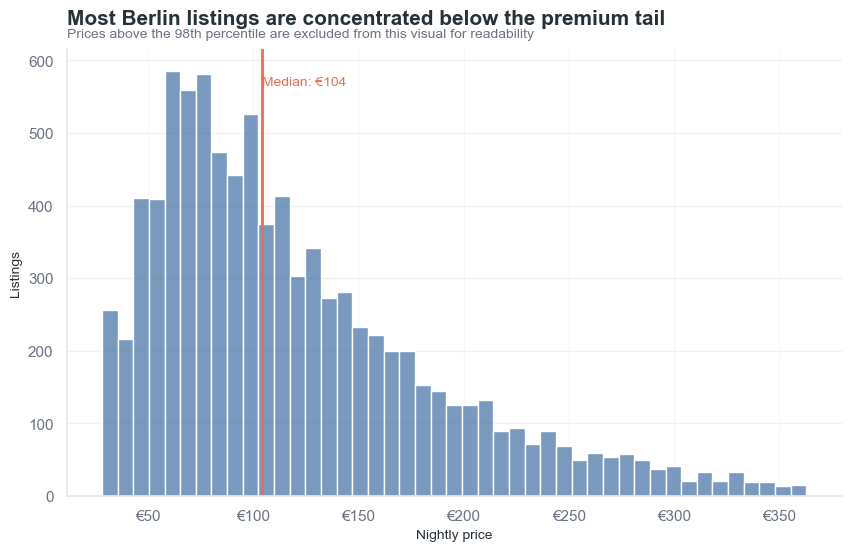

In [21]:
fig, ax = plt.subplots(figsize=(10, 5.8))

price_cap = listings["price"].quantile(0.98)

plot_data = listings.loc[
    listings["price"] <= price_cap,
    "price",
]

median_price = listings["price"].median()

sns.histplot(
    plot_data,
    bins=45,
    color=PALETTE["blue"],
    edgecolor="white",
    ax=ax,
)

ax.axvline(
    median_price,
    color=PALETTE["red"],
    linewidth=2,
)

ax.text(
    median_price,
    ax.get_ylim()[1] * 0.92,
    f"Median: €{median_price:,.0f}",
    color=PALETTE["red"],
    ha="left",
)

ax.xaxis.set_major_formatter(
    FuncFormatter(money_fmt)
)

ax.set_xlabel("Nightly price")
ax.set_ylabel("Listings")

add_chart_title(
    ax,
    "Most Berlin listings are concentrated below the premium tail",
    "Prices above the 98th percentile are excluded from this visual for readability",
)

clean_axis(ax)
save_fig("price_distribution.png")
plt.show()

> Interpretation
> * The cleaned Berlin Airbnb market has a median nightly price of approximately €104, with most listings concentrated below the premium tail.
> * The long right tail indicates that expensive listings form a smaller but meaningful segment, rather than representing the typical market experience.
> * For recommendation logic, price comparisons should be made within traveler-relevant budget ranges instead of comparing every listing against the full market distribution.

## 6.3 Neighborhood Price Differences

This step compares median nightly prices across Berlin neighborhoods with sufficient listing volume.

The goal is to identify where higher-priced submarkets appear in the cleaned Airbnb data and evaluate how location should influence recommendation logic.

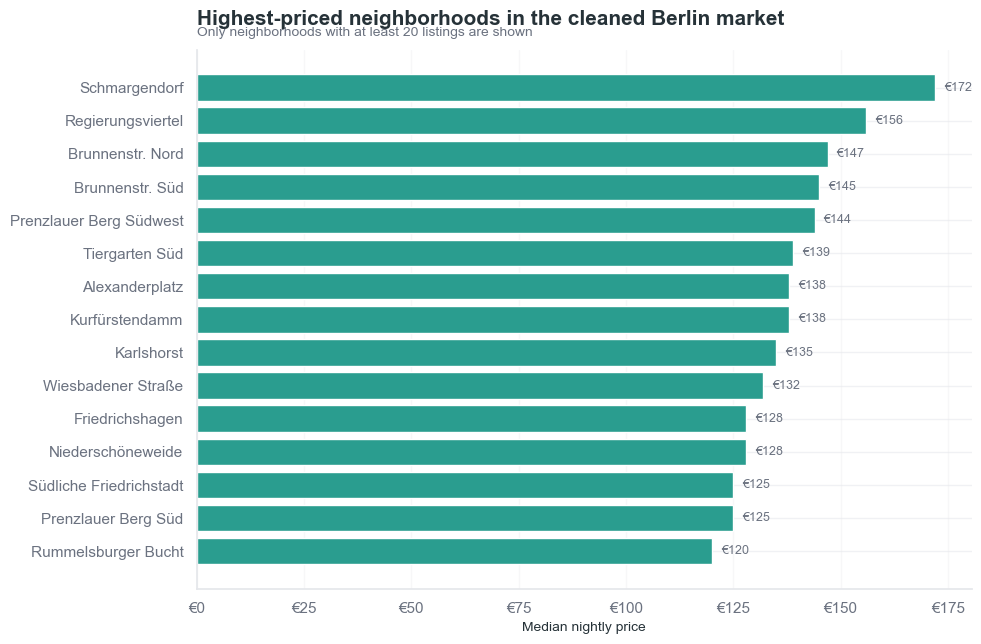

In [22]:
min_neighborhood_size = max(
    20,
    int(len(listings) * 0.002),
)

price_by_neighborhood = (
    neighborhood_summary[
        neighborhood_summary["listing_count"] >= min_neighborhood_size
    ]
    .sort_values("median_price", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    price_by_neighborhood["neighbourhood_cleansed"][::-1],
    price_by_neighborhood["median_price"][::-1],
    color=PALETTE["teal"],
)

ax.xaxis.set_major_formatter(
    FuncFormatter(money_fmt)
)

ax.set_xlabel("Median nightly price")
ax.set_ylabel("")

add_chart_title(
    ax,
    "Highest-priced neighborhoods in the cleaned Berlin market",
    f"Only neighborhoods with at least {min_neighborhood_size} listings are shown",
)

clean_axis(ax)

for i, value in enumerate(price_by_neighborhood["median_price"][::-1]):
    ax.text(
        value + listings["price"].median() * 0.02,
        i,
        f"€{value:,.0f}",
        va="center",
        fontsize=9,
        color=PALETTE["muted"],
    )

save_fig("median_price_by_neighborhood.png")
plt.show()

> Interpretation
> * Median nightly prices vary meaningfully across Berlin neighborhoods, showing that location is an important marketplace segmentation signal.
> * Schmargendorf appears as the highest-priced neighborhood among the visible filtered groups, but this should be interpreted within the cleaned dataset and minimum listing-count threshold.
> * For recommendation logic, neighborhood context should remain a core feature because travelers are likely comparing listings within both budget and location preferences.

## 6.4 Room Type Supply and Quality Signals

This step compares the distribution of room types with their average guest rating scores.

Room type is a core recommendation feature because it defines the traveler’s expected stay experience. An entire home, private room, hotel room, and shared room should not be treated as equivalent options unless the traveler profile explicitly allows that flexibility.

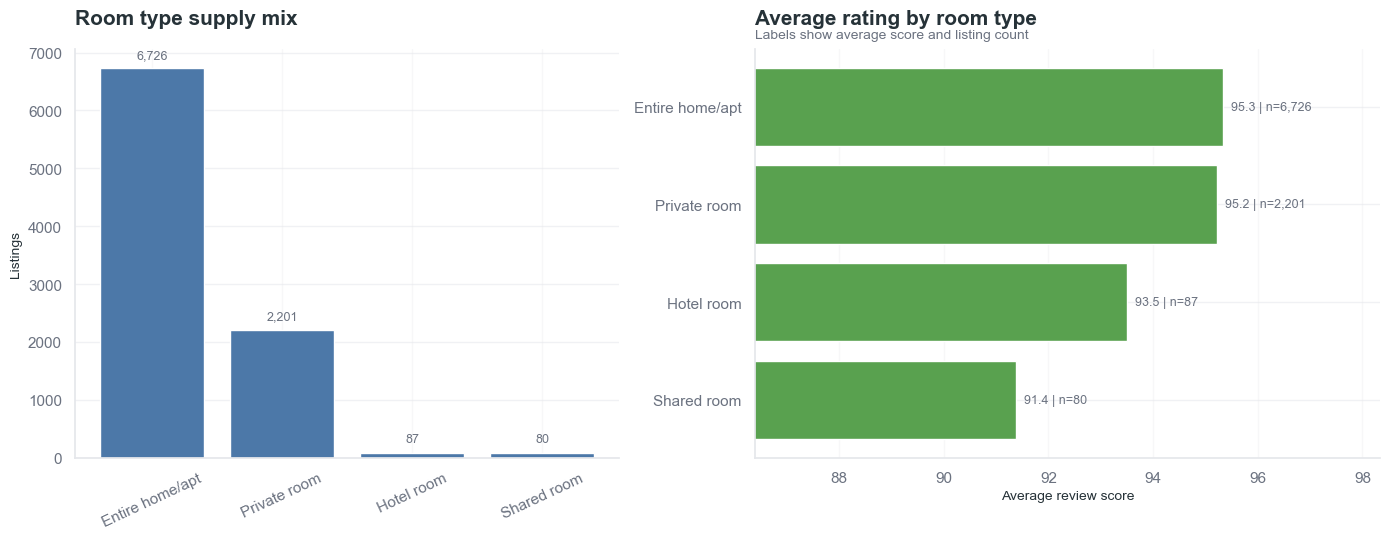

In [23]:
room_counts = (
    listings["room_type"]
    .value_counts()
    .reset_index()
)

room_counts.columns = [
    "room_type",
    "listings",
]

rating_by_room = (
    listings
    .groupby("room_type", as_index=False)
    .agg(
        avg_rating=("review_score", "mean"),
        listings=("listing_id", "nunique"),
    )
    .sort_values("avg_rating", ascending=False)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5),
    gridspec_kw={"width_ratios": [1, 1.15]},
)

axes[0].bar(
    room_counts["room_type"],
    room_counts["listings"],
    color=PALETTE["blue"],
)

axes[0].set_ylabel("Listings")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)

for i, value in enumerate(room_counts["listings"]):
    axes[0].text(
        i,
        value + room_counts["listings"].max() * 0.02,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=PALETTE["muted"],
    )

add_chart_title(
    axes[0],
    "Room type supply mix",
)

clean_axis(axes[0])

axes[1].barh(
    rating_by_room["room_type"][::-1],
    rating_by_room["avg_rating"][::-1],
    color=PALETTE["green"],
)

axes[1].set_xlabel("Average review score")
axes[1].set_ylabel("")

axes[1].set_xlim(
    max(0, rating_by_room["avg_rating"].min() - 5),
    min(100, rating_by_room["avg_rating"].max() + 3),
)

for i, row in enumerate(rating_by_room.iloc[::-1].itertuples()):
    axes[1].text(
        row.avg_rating + 0.15,
        i,
        f"{row.avg_rating:.1f} | n={row.listings:,.0f}",
        va="center",
        fontsize=9,
        color=PALETTE["muted"],
    )

add_chart_title(
    axes[1],
    "Average rating by room type",
    "Labels show average score and listing count",
)

clean_axis(axes[1])

plt.tight_layout()
save_fig("room_type_distribution_and_rating.png")
plt.show()

> Interpretation
> * Entire homes dominate the cleaned Berlin Airbnb supply, while private rooms represent the main alternative accommodation format.
> * Average review scores differ by room type, but smaller categories such as hotel rooms and shared rooms should be interpreted cautiously because they represent much smaller supply segments.
> * A recommender should avoid treating private rooms and entire homes as direct substitutes unless the traveler persona explicitly allows flexibility across stay types.

## 6.5 Superhost Status and Review Quality

This step compares review score distributions between superhosts and non-superhosts.

Superhost status is a potentially useful recommendation signal because it may capture aspects of host reliability and guest experience. Still, it should be treated as a supporting marketplace signal rather than as a standalone measure of listing quality.

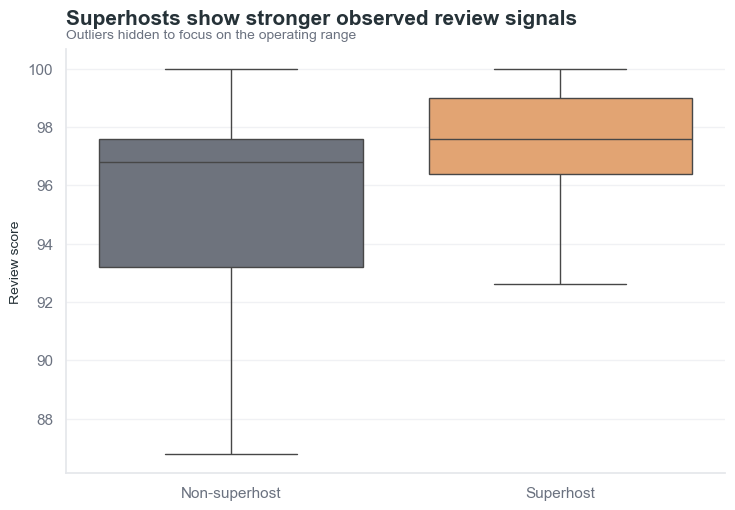

In [24]:
superhost_labels = {
    0: "Non-superhost",
    1: "Superhost",
}

superhost_df = listings.copy()
superhost_df["host_status"] = superhost_df["is_superhost"].map(
    superhost_labels
)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

sns.boxplot(
    data=superhost_df,
    x="host_status",
    y="review_score",
    palette=[
        PALETTE["muted"],
        PALETTE["orange"],
    ],
    ax=ax,
    showfliers=False,
)

ax.set_xlabel("")
ax.set_ylabel("Review score")

add_chart_title(
    ax,
    "Superhosts show stronger observed review signals",
    "Outliers hidden to focus on the operating range",
)

clean_axis(ax)
save_fig("superhost_rating_comparison.png")
plt.show()

superhost_rating_gap = (
    superhost_df
    .groupby("is_superhost")["review_score"]
    .mean()
    .diff()
    .iloc[-1]
)

> Interpretation
> * In the cleaned dataset, superhost listings show an average review score gap of approximately 2.74 points relative to non-superhost listings.
> * This pattern suggests that superhost status may contain useful quality information, although it should not be interpreted as proof that the badge itself causes better guest experiences.
> * For recommendation logic, superhost status can act as a supporting trust signal, but it should complement ratings, reviews, and other listing attributes rather than replace them.

## 6.6 Amenity Signals and Review Quality

This step compares average review scores between listings with and without selected amenities.

Amenities are important recommendation features because they describe practical stay conditions that may matter differently depending on the traveler profile. This analysis does not measure causal impact; it only explores whether certain amenities are associated with stronger review quality signals in the cleaned dataset.

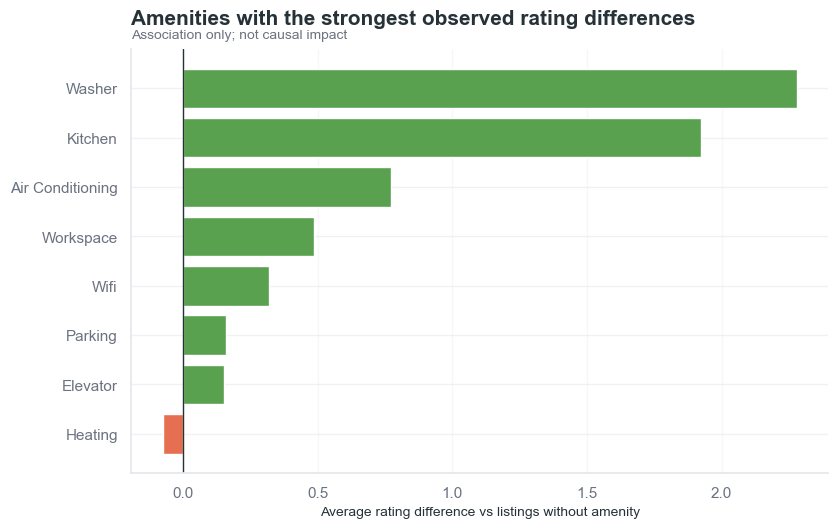

In [25]:
amenity_features = list(amenity_keywords.keys())

amenity_rows = []

for feature in amenity_features:
    has_feature_count = listings[feature].sum()
    without_feature_count = (listings[feature] == 0).sum()

    if has_feature_count > 20 and without_feature_count > 20:
        with_feature_rating = listings.loc[
            listings[feature].eq(1),
            "review_score",
        ].mean()

        without_feature_rating = listings.loc[
            listings[feature].eq(0),
            "review_score",
        ].mean()

        amenity_rows.append({
            "amenity": (
                feature
                .replace("has_", "")
                .replace("_", " ")
                .title()
            ),
            "avg_rating_difference": (
                with_feature_rating
                - without_feature_rating
            ),
            "coverage": listings[feature].mean(),
        })

amenity_quality = (
    pd.DataFrame(amenity_rows)
    .sort_values("avg_rating_difference", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5.5))

colors = [
    PALETTE["green"] if value >= 0 else PALETTE["red"]
    for value in amenity_quality["avg_rating_difference"]
]

ax.barh(
    amenity_quality["amenity"][::-1],
    amenity_quality["avg_rating_difference"][::-1],
    color=colors[::-1],
)

ax.axvline(
    0,
    color=PALETTE["ink"],
    linewidth=1,
)

ax.set_xlabel("Average rating difference vs listings without amenity")
ax.set_ylabel("")

add_chart_title(
    ax,
    "Amenities with the strongest observed rating differences",
    "Association only; not causal impact",
)

clean_axis(ax)
save_fig("amenity_quality_association.png")
plt.show()

> Interpretation
> * Amenity signals help describe listing fit beyond price, location, and room type, especially for traveler profiles with specific practical needs.
> * Washer, kitchen, and air conditioning show the strongest positive rating differences among the selected amenities, but these patterns are associative rather than causal.
> * For recommendation logic, amenities should be used mainly as preference-matching features instead of standalone quality indicators.

## 6.7 Value-for-Money Neighborhood Signals

This step ranks neighborhoods using the engineered value score, which combines review quality and price attractiveness.

The goal is to identify areas that may offer stronger perceived value within the cleaned marketplace. Because the value score is a proxy created from rating and price information, the ranking should be interpreted as a recommendation signal rather than as an objective measure of neighborhood quality.

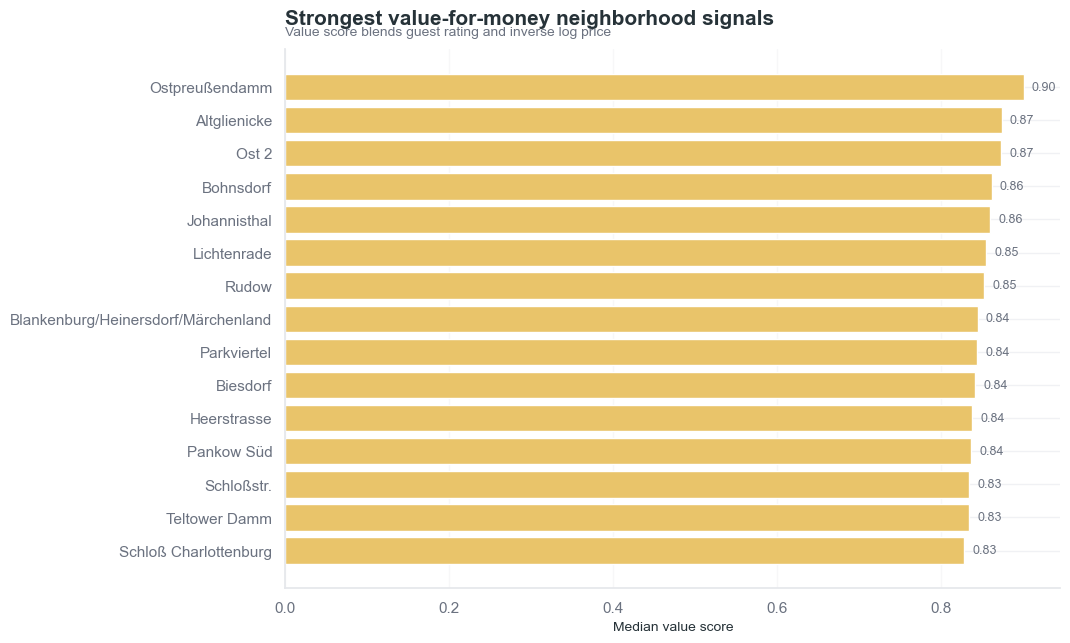

In [26]:
value_neighborhoods = (
    neighborhood_summary[
        neighborhood_summary["listing_count"] >= min_neighborhood_size
    ]
    .sort_values("median_value_score", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    value_neighborhoods["neighbourhood_cleansed"][::-1],
    value_neighborhoods["median_value_score"][::-1],
    color=PALETTE["sand"],
)

ax.set_xlabel("Median value score")
ax.set_ylabel("")

add_chart_title(
    ax,
    "Strongest value-for-money neighborhood signals",
    "Value score blends guest rating and inverse log price",
)

clean_axis(ax)

for i, value in enumerate(value_neighborhoods["median_value_score"][::-1]):
    ax.text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=9,
        color=PALETTE["muted"],
    )

save_fig("value_for_money_neighborhood_ranking.png")
plt.show()

best_value_neighborhood = (
    value_neighborhoods.iloc[0]["neighbourhood_cleansed"]
    if not value_neighborhoods.empty
    else "the top value neighborhood"
)

> Interpretation
> * **Ostpreußendamm** leads the value ranking among neighborhoods with sufficient listing volume under the project’s engineered value-score definition.
> * This ranking reflects a blend of review quality and price attractiveness, not a complete measure of traveler experience or neighborhood quality.
> * For recommendation logic, value-oriented neighborhoods can support budget-conscious discovery and deal surfacing, but they should be combined with traveler preferences around location, room type, and amenities.

## 6.8 Availability, Price, and Quality Signals

This step explores the relationship between listing availability, nightly price, and review quality.

Availability is an important recommendation feature because a listing must be realistically bookable to be useful. However, high availability can reflect different situations: flexible host strategy, seasonality, newer listings, lower demand, or simply calendar management behavior.

For this reason, availability should be treated as a feasibility and context signal rather than as a direct indicator of listing quality or market performance.

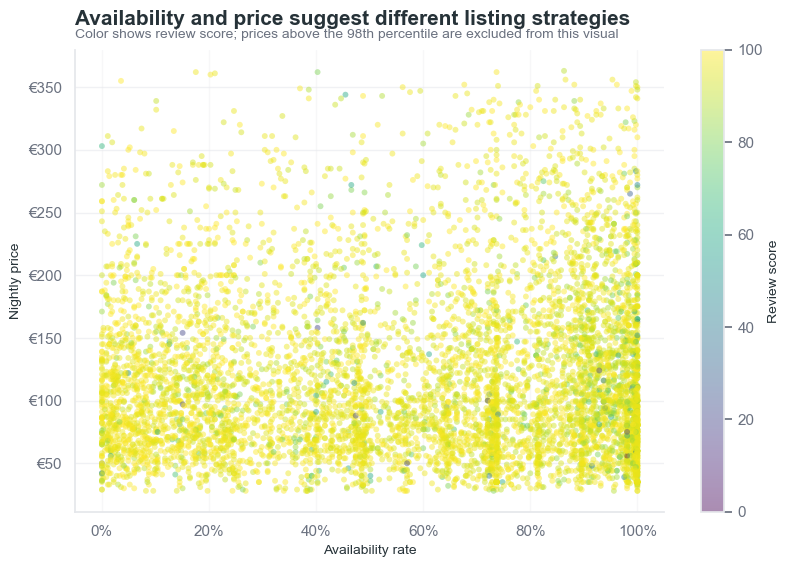

In [27]:
price_cap = listings["price"].quantile(0.98)

sample_scatter = (
    listings[listings["price"] <= price_cap]
    .sample(
        min(len(listings[listings["price"] <= price_cap]), 7000),
        random_state=SEED,
    )
)

fig, ax = plt.subplots(figsize=(9.5, 6))

scatter = ax.scatter(
    sample_scatter["availability_rate"],
    sample_scatter["price"],
    c=sample_scatter["review_score"],
    cmap="viridis",
    alpha=0.45,
    s=18,
    linewidths=0,
)

ax.yaxis.set_major_formatter(
    FuncFormatter(money_fmt)
)

ax.xaxis.set_major_formatter(
    FuncFormatter(pct_fmt)
)

ax.set_xlabel("Availability rate")
ax.set_ylabel("Nightly price")

add_chart_title(
    ax,
    "Availability and price suggest different listing strategies",
    "Color shows review score; prices above the 98th percentile are excluded from this visual",
)

clean_axis(ax)

cbar = plt.colorbar(
    scatter,
    ax=ax,
)

cbar.set_label("Review score")

save_fig("availability_vs_price.png")
plt.show()

> Interpretation
> * Availability varies across both low-priced and high-priced listings, suggesting that bookability is not explained by price alone.
> * High availability should not be automatically rewarded in recommendation logic because it may reflect seasonality, host strategy, newer listings, or weaker demand.
> * For a hybrid ranker, availability is most useful as a feasibility signal when combined with price, review quality, location, and traveler preferences.

## 6.9 Review Velocity by Neighborhood

This step compares average review activity across neighborhoods using reviews per month.

Review velocity can help identify areas with stronger observed guest activity, but it should be treated as an engagement proxy rather than a direct measure of demand. The dataset does not include booking volume, search impressions, clicks, or conversion events.

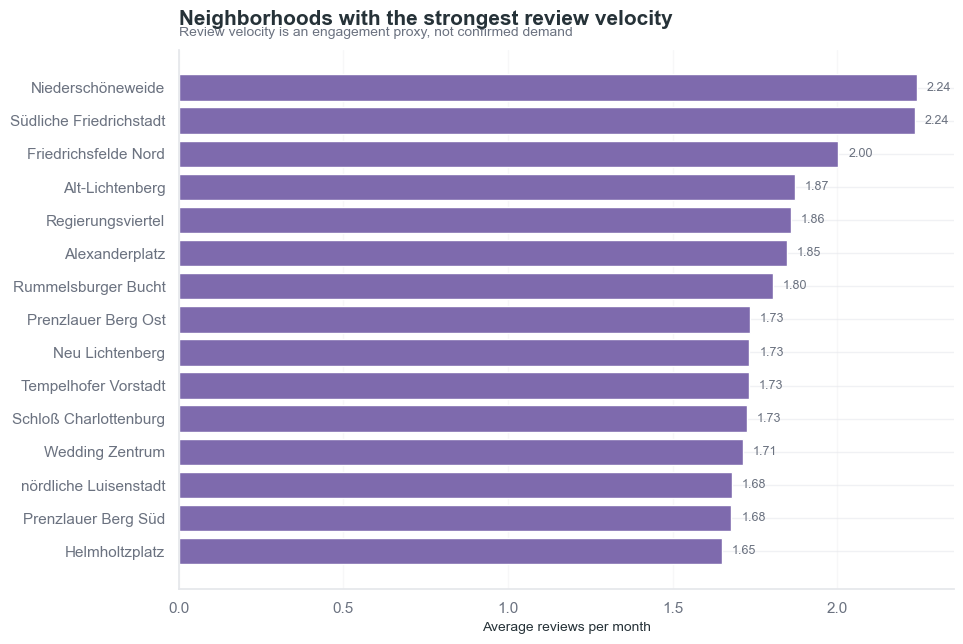

In [28]:
rpm_neighborhoods = (
    neighborhood_summary[
        neighborhood_summary["listing_count"] >= min_neighborhood_size
    ]
    .sort_values("avg_reviews_per_month", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    rpm_neighborhoods["neighbourhood_cleansed"][::-1],
    rpm_neighborhoods["avg_reviews_per_month"][::-1],
    color=PALETTE["purple"],
)

ax.set_xlabel("Average reviews per month")
ax.set_ylabel("")

add_chart_title(
    ax,
    "Neighborhoods with the strongest review velocity",
    "Review velocity is an engagement proxy, not confirmed demand",
)

clean_axis(ax)

for i, value in enumerate(rpm_neighborhoods["avg_reviews_per_month"][::-1]):
    ax.text(
        value + 0.03,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=9,
        color=PALETTE["muted"],
    )

save_fig("reviews_per_month_by_neighborhood.png")
plt.show()

> Interpretation
> * Review velocity varies meaningfully across Berlin neighborhoods, suggesting that guest activity is not evenly distributed across the marketplace.
> * Niederschöneweide and Südliche Friedrichstadt show the strongest average review activity among neighborhoods with sufficient listing volume.
> * Reviews per month can support recommendation ranking as an engagement signal, but it should not be interpreted as confirmed demand, booking volume, or conversion performance.

## 6.10 Feature Relationships for Ranking Design

This step examines correlations between selected numeric features that may later be used in recommendation ranking.

The goal is to identify which signals capture distinct dimensions of listing relevance and which variables may be partially redundant. This helps guide feature selection before building the recommendation logic.

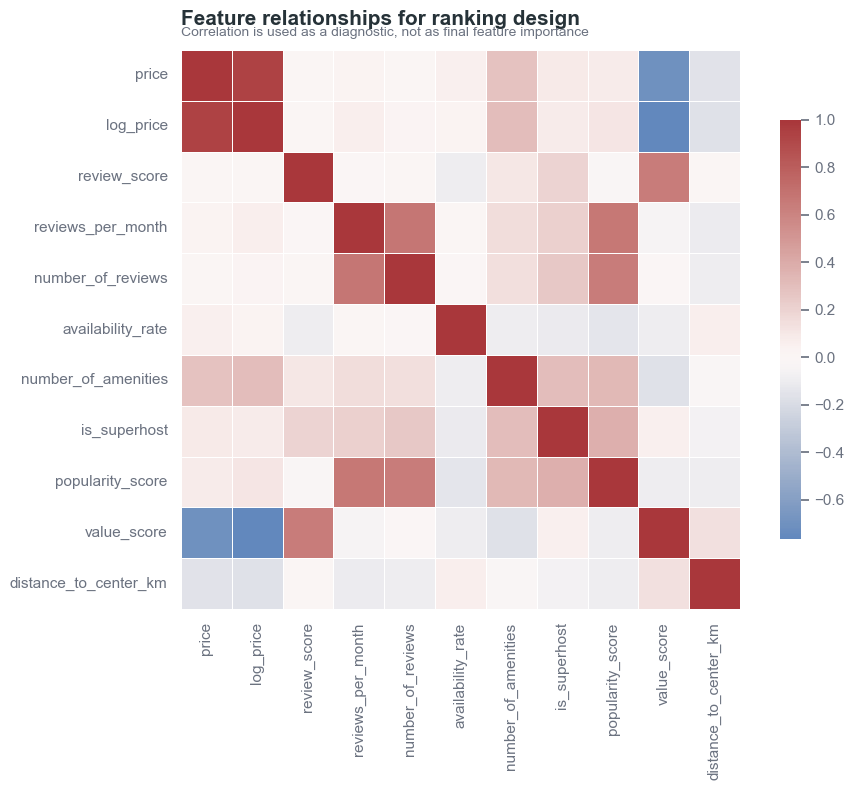

In [29]:
corr_df = listings[quality_numeric_cols].copy()
corr = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    linewidths=0.5,
    annot=False,
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.75},
)

add_chart_title(
    ax,
    "Feature relationships for ranking design",
    "Correlation is used as a diagnostic, not as final feature importance",
)

plt.tight_layout()
save_fig("correlation_heatmap.png")
plt.show()

> Interpretation
> * The correlation structure helps identify which ranking signals overlap and which capture different dimensions of listing relevance.
> * Price and log price are strongly related, while review volume metrics are also closely connected to the engineered popularity score.
> * A hybrid recommender should avoid over-weighting redundant variables and instead combine complementary signals such as price, quality, availability, popularity, and location context.
> * These correlations are exploratory diagnostics, not causal explanations or final evidence of feature importance.

# 7. Review Text and Sentiment Analysis

This section adds the guest voice to the recommendation analysis by extracting signals from public Airbnb review text.

Reviews can provide useful context beyond structured listing attributes because guests often describe practical experience dimensions such as cleanliness, location, communication, comfort, noise, and overall stay quality.

The analysis focuses on three product-oriented questions:

- **Guest language:** What themes appear most often in review text?
- **Sentiment signal:** Can review sentiment provide an additional quality proxy beyond star ratings?
- **Recommendation context:** Do textual signals help describe listings in a way that supports more personalized discovery?

Because Airbnb reviews are multilingual and the notebook may run in different local environments, sentiment scoring is treated as a proxy rather than a definitive measure of guest satisfaction.

## 7.1 Review Text Cleaning and Sentiment Scoring

This step cleans review text, applies a locally available sentiment method, and aggregates review-level language signals into listing-level features.

The sentiment method is selected defensively based on the libraries available in the environment. If stronger sentiment libraries are unavailable, the notebook falls back to a simple lexicon-based approach.

Because this fallback is limited and the reviews may be multilingual, sentiment should be interpreted as an approximate text signal rather than a robust multilingual sentiment model.

In [30]:
def clean_review_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(
        r"[^a-zA-ZäöüÄÖÜßáéíóúàèìòùâêîôûñç\s]",
        " ",
        text,
    )
    text = re.sub(r"\s+", " ", text).strip()

    return text


sentiment_method = "lexicon_fallback"

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

    analyzer = SentimentIntensityAnalyzer()

    def sentiment_score(text):
        return analyzer.polarity_scores(str(text))["compound"]

    sentiment_method = "vaderSentiment"

except Exception:
    try:
        from nltk.sentiment import SentimentIntensityAnalyzer

        analyzer = SentimentIntensityAnalyzer()

        def sentiment_score(text):
            return analyzer.polarity_scores(str(text))["compound"]

        sentiment_method = "nltk_vader"

    except Exception:
        try:
            from textblob import TextBlob

            def sentiment_score(text):
                return float(TextBlob(str(text)).sentiment.polarity)

            sentiment_method = "textblob"

        except Exception:
            POSITIVE_WORDS = set(
                """
                great good excellent perfect clean comfortable friendly helpful
                amazing nice easy beautiful quiet spacious central recommend
                wonderful lovely best
                """.split()
            )

            NEGATIVE_WORDS = set(
                """
                bad poor dirty noisy difficult uncomfortable small problem
                broken rude worst terrible disappointing
                """.split()
            )

            def sentiment_score(text):
                words = clean_review_text(text).split()

                if not words:
                    return 0.0

                positive_count = sum(
                    word in POSITIVE_WORDS
                    for word in words
                )

                negative_count = sum(
                    word in NEGATIVE_WORDS
                    for word in words
                )

                return (
                    positive_count - negative_count
                ) / max(
                    1,
                    positive_count + negative_count,
                )


NLP_SAMPLE_LIMIT = 150_000

nlp_reviews = reviews_with_text[
    [
        "listing_id",
        "reviewer_id",
        "date",
        "comments",
        "review_length_words",
    ]
].copy()

if len(nlp_reviews) > NLP_SAMPLE_LIMIT:
    nlp_reviews = nlp_reviews.sample(
        NLP_SAMPLE_LIMIT,
        random_state=SEED,
    )

nlp_reviews["clean_comments"] = nlp_reviews["comments"].apply(
    clean_review_text
)

nlp_reviews = nlp_reviews[
    nlp_reviews["clean_comments"].str.len() > 10
].copy()

nlp_reviews["sentiment_score"] = nlp_reviews["clean_comments"].apply(
    sentiment_score
)

sentiment_summary = (
    nlp_reviews
    .groupby("listing_id")
    .agg(
        review_count_nlp=("listing_id", "size"),
        average_sentiment=("sentiment_score", "mean"),
        average_review_length_nlp=("review_length_words", "mean"),
        review_summary_text=(
            "clean_comments",
            lambda x: " ".join(list(x.head(12))),
        ),
    )
    .reset_index()
)

existing_sentiment_cols = [
    "review_count_nlp",
    "average_sentiment",
    "average_review_length_nlp",
    "review_summary_text",
]

listings = listings.drop(
    columns=[
        col for col in existing_sentiment_cols
        if col in listings.columns
    ]
)

listings = listings.merge(
    sentiment_summary,
    on="listing_id",
    how="left",
)

listings["average_sentiment"] = listings["average_sentiment"].fillna(
    listings["average_sentiment"].median()
)

listings["average_review_length_nlp"] = listings[
    "average_review_length_nlp"
].fillna(
    listings["avg_review_length"]
)

listings["review_count_nlp"] = listings["review_count_nlp"].fillna(0)
listings["review_summary_text"] = listings["review_summary_text"].fillna("")

listings["sentiment_score_norm"] = minmax(
    listings["average_sentiment"]
)

nlp_summary_table = pd.DataFrame({
    "metric": [
        "sentiment method",
        "review rows used for NLP",
        "listings with NLP review text",
    ],
    "value": [
        sentiment_method,
        f"{len(nlp_reviews):,}",
        f"{sentiment_summary['listing_id'].nunique():,}",
    ],
})

nlp_summary_table

,metric,value
0,sentiment method,lexicon_fallback
1,review rows used for NLP,"148,219"
2,listings with NLP review text,"9,028"


> Interpretation
> * The NLP workflow uses 148,219 review records after sampling and text-length filtering, creating a scalable review-text layer for the recommendation analysis.
> * NLP review text is available for 9,028 listings, which means the text-based layer covers most of the cleaned listing base but is still not complete for every listing.
> * The local environment falls back to a simple lexicon-based sentiment method, so sentiment should be interpreted as a lightweight proxy rather than a robust multilingual sentiment model.
> * Because reviews are public, multilingual, and unevenly distributed across listings, sentiment features should support recommendation context rather than dominate ranking decisions.

## 7.2 Sentiment Score Distribution

This step examines the distribution of review sentiment scores generated from guest comments.

Because the local environment uses a simple lexicon-based fallback method, the sentiment scores should be interpreted as coarse proxy signals rather than precise emotional measurements. The goal is to understand whether review text adds useful directional context to the recommendation workflow.

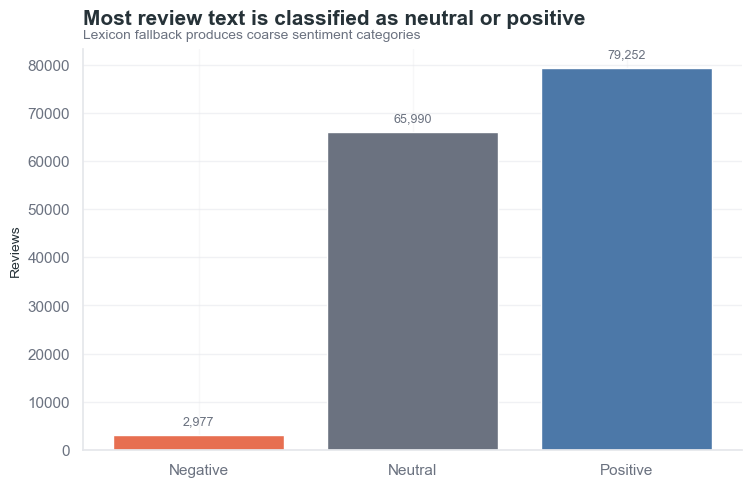

In [31]:
def sentiment_label(score):
    if score > 0.05:
        return "Positive"
    if score < -0.05:
        return "Negative"
    return "Neutral"


nlp_reviews["sentiment_label"] = nlp_reviews["sentiment_score"].apply(
    sentiment_label
)

sentiment_counts = (
    nlp_reviews["sentiment_label"]
    .value_counts()
    .reindex(["Negative", "Neutral", "Positive"])
    .reset_index()
)

sentiment_counts.columns = [
    "sentiment_label",
    "reviews",
]

fig, ax = plt.subplots(figsize=(8.5, 5.2))

ax.bar(
    sentiment_counts["sentiment_label"],
    sentiment_counts["reviews"],
    color=[
        PALETTE["red"],
        PALETTE["muted"],
        PALETTE["blue"],
    ],
)

ax.set_xlabel("")
ax.set_ylabel("Reviews")

add_chart_title(
    ax,
    "Most review text is classified as neutral or positive",
    "Lexicon fallback produces coarse sentiment categories",
)

clean_axis(ax)

for i, value in enumerate(sentiment_counts["reviews"]):
    ax.text(
        i,
        value + sentiment_counts["reviews"].max() * 0.02,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=PALETTE["muted"],
    )

save_fig("sentiment_category_distribution.png")
plt.show()

> Interpretation
> * The fallback sentiment method classifies most usable review text as neutral or positive, which is consistent with the generally positive nature of public Airbnb reviews.
> * Because this sentiment layer is based on a simple lexicon fallback, it should be treated as a coarse directional proxy rather than a robust multilingual sentiment model.
> * For recommendation logic, sentiment is more useful as a supporting context signal than as a strict quality filter.

## 7.3 Positive Review Language

This step identifies the most distinctive terms appearing in high-sentiment guest reviews.

The goal is to understand which words and short phrases are commonly associated with positive guest experiences. These terms can help translate free-text reviews into interpretable recommendation context, but they should not be treated as a complete topic model or causal explanation of satisfaction.

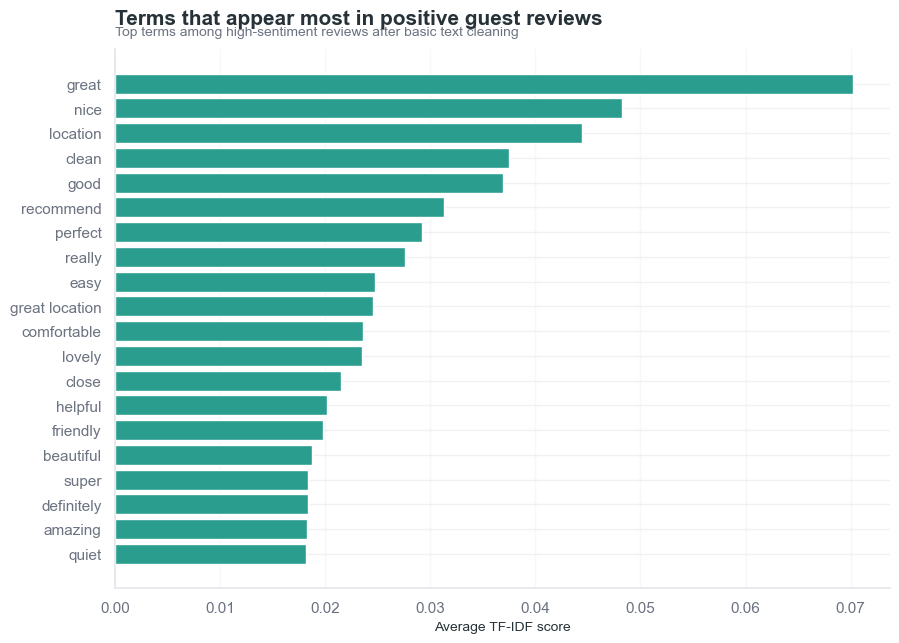

In [32]:
positive_reviews = nlp_reviews.loc[
    nlp_reviews["sentiment_score"]
    >= nlp_reviews["sentiment_score"].quantile(0.70),
    "clean_comments",
]

custom_stop_words = list(
    ENGLISH_STOP_WORDS.union({
        "berlin",
        "airbnb",
        "apartment",
        "apartments",
        "place",
        "stay",
        "stayed",
        "staying",
        "host",
        "hosts",
        "room",
        "flat",
        "wohnung",
        "und",
        "die",
        "der",
        "das",
        "ist",
        "war",
        "sehr",
    })
)

if len(positive_reviews) >= 20:
    tfidf_terms = TfidfVectorizer(
        max_features=1200,
        min_df=5,
        ngram_range=(1, 2),
        stop_words=custom_stop_words,
    )

    positive_matrix = tfidf_terms.fit_transform(
        positive_reviews
    )

    term_scores = np.asarray(
        positive_matrix.mean(axis=0)
    ).ravel()

    top_terms = (
        pd.DataFrame({
            "term": tfidf_terms.get_feature_names_out(),
            "score": term_scores,
        })
        .sort_values("score", ascending=False)
        .head(20)
    )

else:
    top_terms = pd.DataFrame({
        "term": [],
        "score": [],
    })


fig, ax = plt.subplots(figsize=(10, 7))

if not top_terms.empty:
    ax.barh(
        top_terms["term"][::-1],
        top_terms["score"][::-1],
        color=PALETTE["teal"],
    )

ax.set_xlabel("Average TF-IDF score")
ax.set_ylabel("")

add_chart_title(
    ax,
    "Terms that appear most in positive guest reviews",
    "Top terms among high-sentiment reviews after basic text cleaning",
)

clean_axis(ax)
save_fig("top_positive_review_terms.png")
plt.show()

> Interpretation
> * Positive review language highlights both general satisfaction terms and practical stay signals such as location, cleanliness, comfort, helpfulness, and quietness.
> * These terms help translate guest comments into recommendation context, especially when structured listing attributes do not fully capture the lived experience.
> * Because this analysis uses basic TF-IDF on cleaned review text, the results should be interpreted as exploratory language signals rather than a complete semantic understanding of guest experience.

## 7.4 Sentiment and Rating Relationship

This step compares average review sentiment with listing review scores.

The goal is to evaluate whether the text-based sentiment signal adds information beyond structured star ratings. Because sentiment is generated using a fallback lexicon method, this comparison should be interpreted as an exploratory diagnostic rather than a precise validation of review emotion.

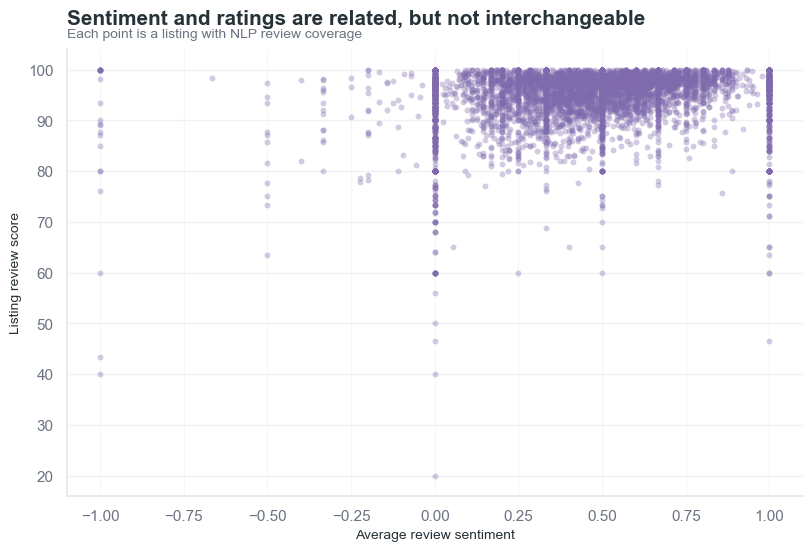

In [33]:
sentiment_rating = listings[
    listings["review_count_nlp"] > 0
].sample(
    min((listings["review_count_nlp"] > 0).sum(), 7000),
    random_state=SEED,
)

fig, ax = plt.subplots(figsize=(9.5, 5.8))

ax.scatter(
    sentiment_rating["average_sentiment"],
    sentiment_rating["review_score"],
    alpha=0.35,
    s=18,
    color=PALETTE["purple"],
    linewidths=0,
)

ax.set_xlabel("Average review sentiment")
ax.set_ylabel("Listing review score")

add_chart_title(
    ax,
    "Sentiment and ratings are related, but not interchangeable",
    "Each point is a listing with NLP review coverage",
)

clean_axis(ax)
save_fig("sentiment_vs_rating.png")
plt.show()

corr_sentiment_rating = (
    sentiment_rating[
        [
            "average_sentiment",
            "review_score",
        ]
    ]
    .corr()
    .iloc[0, 1]
    if len(sentiment_rating) > 2
    else np.nan
)

> Interpretation
> * The sentiment-rating correlation is approximately 0.19 in this sample, suggesting that text sentiment and star ratings are related but not redundant.
> * This supports using sentiment as a complementary context signal rather than as a replacement for structured review scores.
> * Because the sentiment layer is based on a lexicon fallback and multilingual public reviews, the relationship should be interpreted as exploratory rather than as a precise measurement of guest satisfaction.

## 7.5 Neighborhood-Level Sentiment Signals

This step aggregates listing-level sentiment scores by neighborhood to explore how guest language varies across Berlin’s local Airbnb submarkets.

The goal is not to rank neighborhoods as objectively better or worse, but to identify whether review text provides additional context that may help distinguish areas with similar price, rating, or availability profiles.

Because the sentiment layer is based on a fallback lexicon method and public Airbnb reviews are multilingual, these results should be interpreted as directional neighborhood signals rather than precise measures of guest satisfaction.

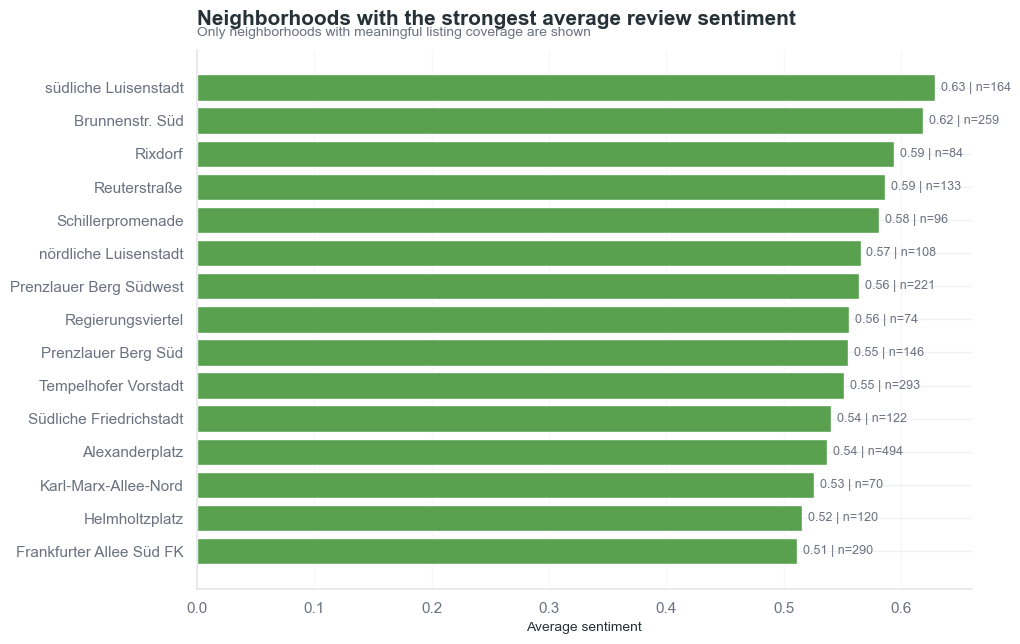

In [34]:
sentiment_neighborhood = (
    listings[listings["review_count_nlp"] > 0]
    .groupby("neighbourhood_cleansed")
    .agg(
        avg_sentiment=("average_sentiment", "mean"),
        listings=("listing_id", "nunique"),
    )
    .reset_index()
)

sentiment_neighborhood = (
    sentiment_neighborhood[
        sentiment_neighborhood["listings"] >= min_neighborhood_size
    ]
    .sort_values("avg_sentiment", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    sentiment_neighborhood["neighbourhood_cleansed"][::-1],
    sentiment_neighborhood["avg_sentiment"][::-1],
    color=PALETTE["green"],
)

ax.set_xlabel("Average sentiment")
ax.set_ylabel("")

add_chart_title(
    ax,
    "Neighborhoods with the strongest average review sentiment",
    "Only neighborhoods with meaningful listing coverage are shown",
)

clean_axis(ax)

for i, row in enumerate(sentiment_neighborhood.iloc[::-1].itertuples()):
    ax.text(
        row.avg_sentiment + 0.005,
        i,
        f"{row.avg_sentiment:.2f} | n={row.listings:,.0f}",
        va="center",
        fontsize=9,
        color=PALETTE["muted"],
    )

save_fig("average_sentiment_by_neighborhood.png")
plt.show()

> Interpretation
> * Average review sentiment varies across Berlin neighborhoods, suggesting that guest language can add contextual information beyond price and structured listing attributes.
> * Because the sentiment layer is based on a lexicon fallback and multilingual public reviews, neighborhood-level differences should be interpreted as directional signals rather than precise measures of guest satisfaction.
> * For recommendation logic, neighborhood sentiment can help differentiate areas with similar price and rating profiles, but it should be used as a supporting context feature rather than a dominant ranking factor.

## 7.6 Review Depth and Text Coverage

This step examines how much review text is available across listings with NLP coverage.

Average review length is not treated as a quality score. Instead, it helps estimate the depth of guest language available for sentiment aggregation, semantic matching, and review-based recommendation context.

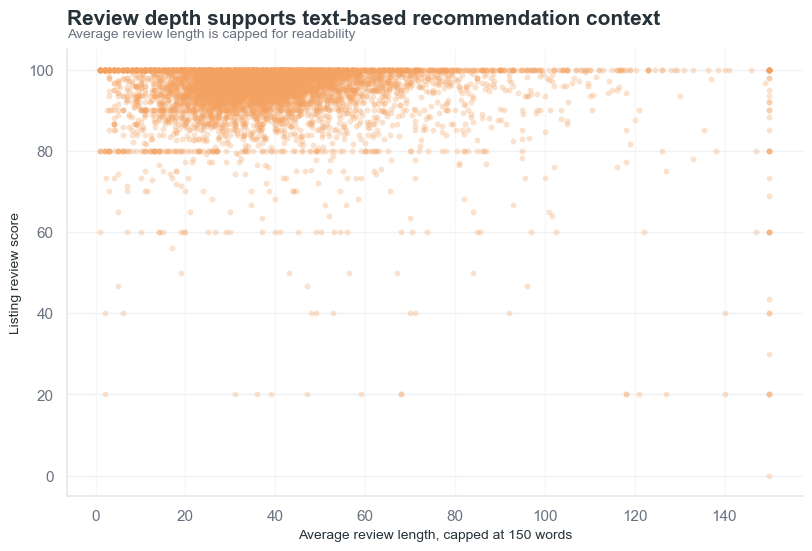

In [35]:
length_rating = (
    listings[listings["average_review_length_nlp"].gt(0)]
    .sample(
        min((listings["average_review_length_nlp"].gt(0)).sum(), 7000),
        random_state=SEED,
    )
)

review_length_cap = 150

fig, ax = plt.subplots(figsize=(9.5, 5.8))

ax.scatter(
    length_rating["average_review_length_nlp"].clip(upper=review_length_cap),
    length_rating["review_score"],
    alpha=0.30,
    s=18,
    color=PALETTE["orange"],
    linewidths=0,
)

ax.set_xlabel("Average review length, capped at 150 words")
ax.set_ylabel("Listing review score")

add_chart_title(
    ax,
    "Review depth supports text-based recommendation context",
    "Average review length is capped for readability",
)

clean_axis(ax)
save_fig("review_length_vs_rating.png")
plt.show()

> Interpretation
> * Average review length does not behave like a direct quality score, since both positive and negative experiences can generate longer comments.
> * Listings with deeper review text provide more language context for sentiment aggregation, semantic matching, and recommendation explanation.
> * For recommendation logic, review depth should be used as a text-coverage signal rather than as evidence of listing quality or guest satisfaction.

## 7.7 Semantic Review Vectors

This step prepares text-based semantic representations from listing review summaries.

When sentence-transformer embeddings are available, the notebook uses them to create denser semantic vectors from guest language. When they are not available, the workflow falls back to TF-IDF vectors based on review summary text.

The goal is to create a review-text similarity layer that can later support semantic fallback recommendations, especially when structured listing attributes are not enough to describe the guest experience.

In [36]:
HAS_SENTENCE_TRANSFORMERS = False

semantic_listing_ids = []
semantic_matrix = None
semantic_method = "tfidf_review_summary"

review_summary_for_semantics = listings[
    [
        "listing_id",
        "review_summary_text",
    ]
].copy()

review_summary_for_semantics = review_summary_for_semantics[
    review_summary_for_semantics["review_summary_text"].str.len() > 20
].copy()

try:
    from sentence_transformers import SentenceTransformer

    if len(review_summary_for_semantics) > 0:
        model = SentenceTransformer(
            "all-MiniLM-L6-v2"
        )

        semantic_sample = review_summary_for_semantics.sample(
            min(len(review_summary_for_semantics), 3000),
            random_state=SEED,
        )

        semantic_listing_ids = semantic_sample["listing_id"].tolist()

        semantic_matrix = model.encode(
            semantic_sample["review_summary_text"].tolist(),
            show_progress_bar=False,
            normalize_embeddings=True,
        )

        HAS_SENTENCE_TRANSFORMERS = True
        semantic_method = "sentence_transformers_all_minilm_l6_v2"

except Exception:
    if len(review_summary_for_semantics) > 0:
        semantic_vectorizer = TfidfVectorizer(
            max_features=3000,
            min_df=2,
            stop_words=custom_stop_words,
            ngram_range=(1, 2),
        )

        semantic_matrix = semantic_vectorizer.fit_transform(
            review_summary_for_semantics["review_summary_text"]
        )

        semantic_listing_ids = review_summary_for_semantics[
            "listing_id"
        ].tolist()

        semantic_method = "tfidf_review_summary"


semantic_summary_table = pd.DataFrame({
    "metric": [
        "semantic method",
        "listings with review text available",
        "listings with semantic review vectors",
    ],
    "value": [
        semantic_method,
        f"{len(review_summary_for_semantics):,}",
        f"{len(semantic_listing_ids):,}",
    ],
})

semantic_summary_table

,metric,value
0,semantic method,tfidf_review_summary
1,listings with review text available,"6,127"
2,listings with semantic review vectors,"6,127"


> Interpretation
> * Semantic review vectors are created for 6,127 listings with enough review text to support text-based similarity.
> * The local environment uses a TF-IDF fallback rather than sentence-transformer embeddings, so the semantic layer captures term-based similarity rather than deep contextual meaning.
> * These vectors are still useful for recommendation fallback logic, especially when guest language provides context that structured fields cannot fully represent.
> * Because semantic coverage is partial, review-text similarity should complement the main recommendation signals rather than replace listing, price, location, and availability features.

# 8. Geospatial Marketplace Analysis

This section explores how Berlin Airbnb listings are distributed geographically and how location relates to price, supply density, and recommendation context.

Location is one of the most important signals in accommodation discovery because travelers often compare listings within specific neighborhoods, mobility zones, or proximity preferences. However, centrality should not be treated as universally better: different traveler profiles may prioritize price, neighborhood identity, comfort, accessibility, or local experience.

The analysis focuses on three product-oriented questions:

- **Supply density:** Where are Airbnb listings most concentrated across Berlin?
- **Spatial pricing:** Where do higher-priced listings appear geographically?
- **Ranking context:** How should location support recommendation logic without over-prioritizing only central listings?

The recommendation framework uses location in two complementary ways: exact coordinates for spatial distance and density analysis, and neighborhood-level aggregates for ranking context and traveler segmentation.

## 8.1 Listing Density and Spatial Price Patterns

This step maps listing concentration and nightly prices across Berlin using latitude and longitude.

The goal is to understand how supply and price vary spatially before using location as a recommendation signal. These maps are exploratory and should be interpreted as spatial context rather than precise neighborhood boundaries or causal evidence of pricing behavior.

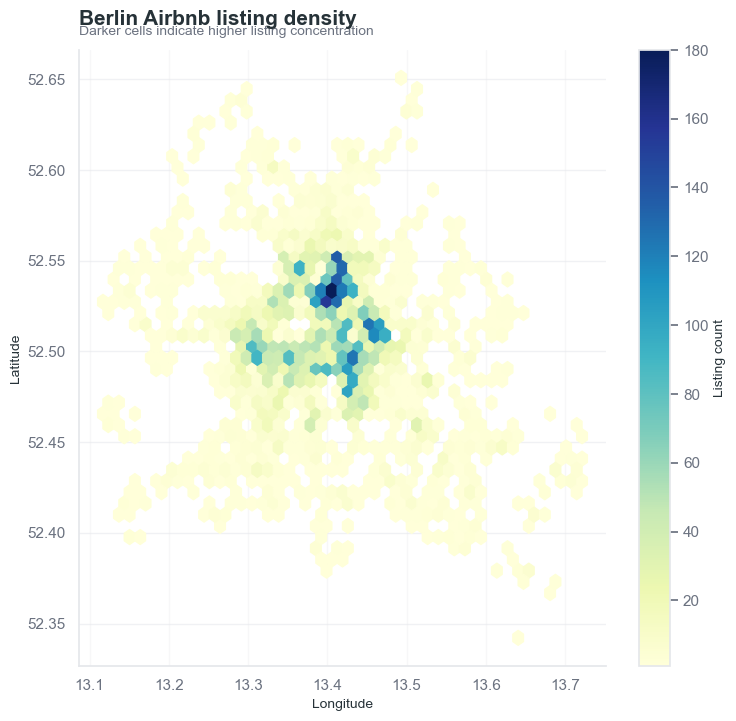

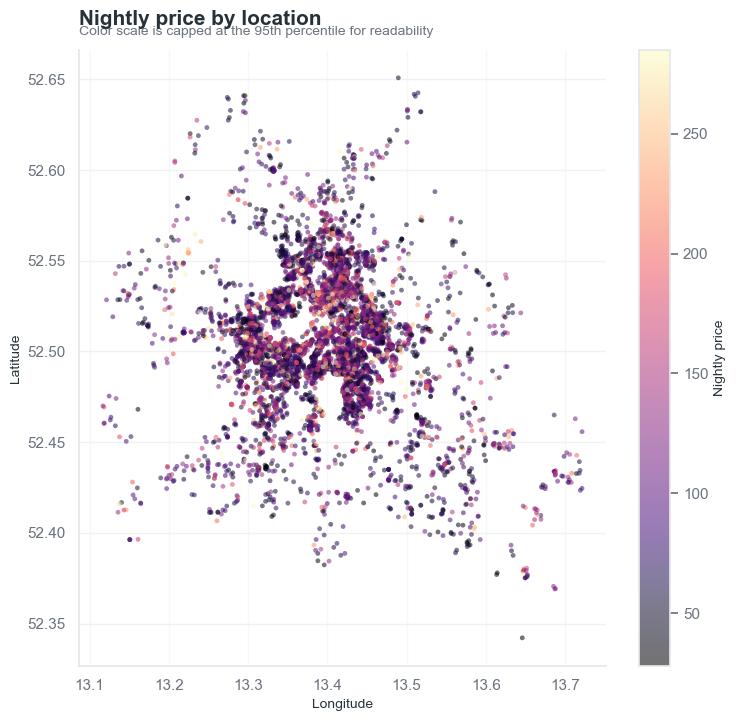

In [37]:
geo_sample = (
    listings
    .dropna(subset=["latitude", "longitude"])
    .sample(
        min(len(listings), 12000),
        random_state=SEED,
    )
)

fig, ax = plt.subplots(figsize=(8.5, 8))

density_map = ax.hexbin(
    geo_sample["longitude"],
    geo_sample["latitude"],
    gridsize=45,
    cmap="YlGnBu",
    mincnt=1,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

add_chart_title(
    ax,
    "Berlin Airbnb listing density",
    "Darker cells indicate higher listing concentration",
)

clean_axis(ax)

cbar = plt.colorbar(
    density_map,
    ax=ax,
)

cbar.set_label("Listing count")

save_fig("listing_density_map.png")
plt.show()


price_color_cap = listings["price"].quantile(0.95)

geo_sample["price_for_color"] = geo_sample["price"].clip(
    upper=price_color_cap
)

fig, ax = plt.subplots(figsize=(8.5, 8))

price_map = ax.scatter(
    geo_sample["longitude"],
    geo_sample["latitude"],
    c=geo_sample["price_for_color"],
    cmap="magma",
    s=12,
    alpha=0.55,
    linewidths=0,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

add_chart_title(
    ax,
    "Nightly price by location",
    "Color scale is capped at the 95th percentile for readability",
)

clean_axis(ax)

cbar = plt.colorbar(
    price_map,
    ax=ax,
)

cbar.set_label("Nightly price")

save_fig("price_map.png")
plt.show()

> Interpretation
> * Airbnb supply is visibly concentrated in central and inner-city areas, suggesting that location density is an important marketplace structure signal.
> * Higher-priced listings appear across multiple areas rather than forming a single isolated cluster, which suggests that price cannot be explained by centrality alone.
> * For recommendation logic, spatial context should help balance proximity, neighborhood preference, price, and value instead of simply prioritizing the most central listings.

## 8.2 Neighborhood-Level Geospatial Context

This step combines neighborhood boundary data with the aggregated marketplace indicators created earlier in the analysis.

The choropleth maps provide a neighborhood-level view of price, supply concentration, value score, and guest rating patterns. This helps translate raw coordinates into a more interpretable location context for recommendation design.

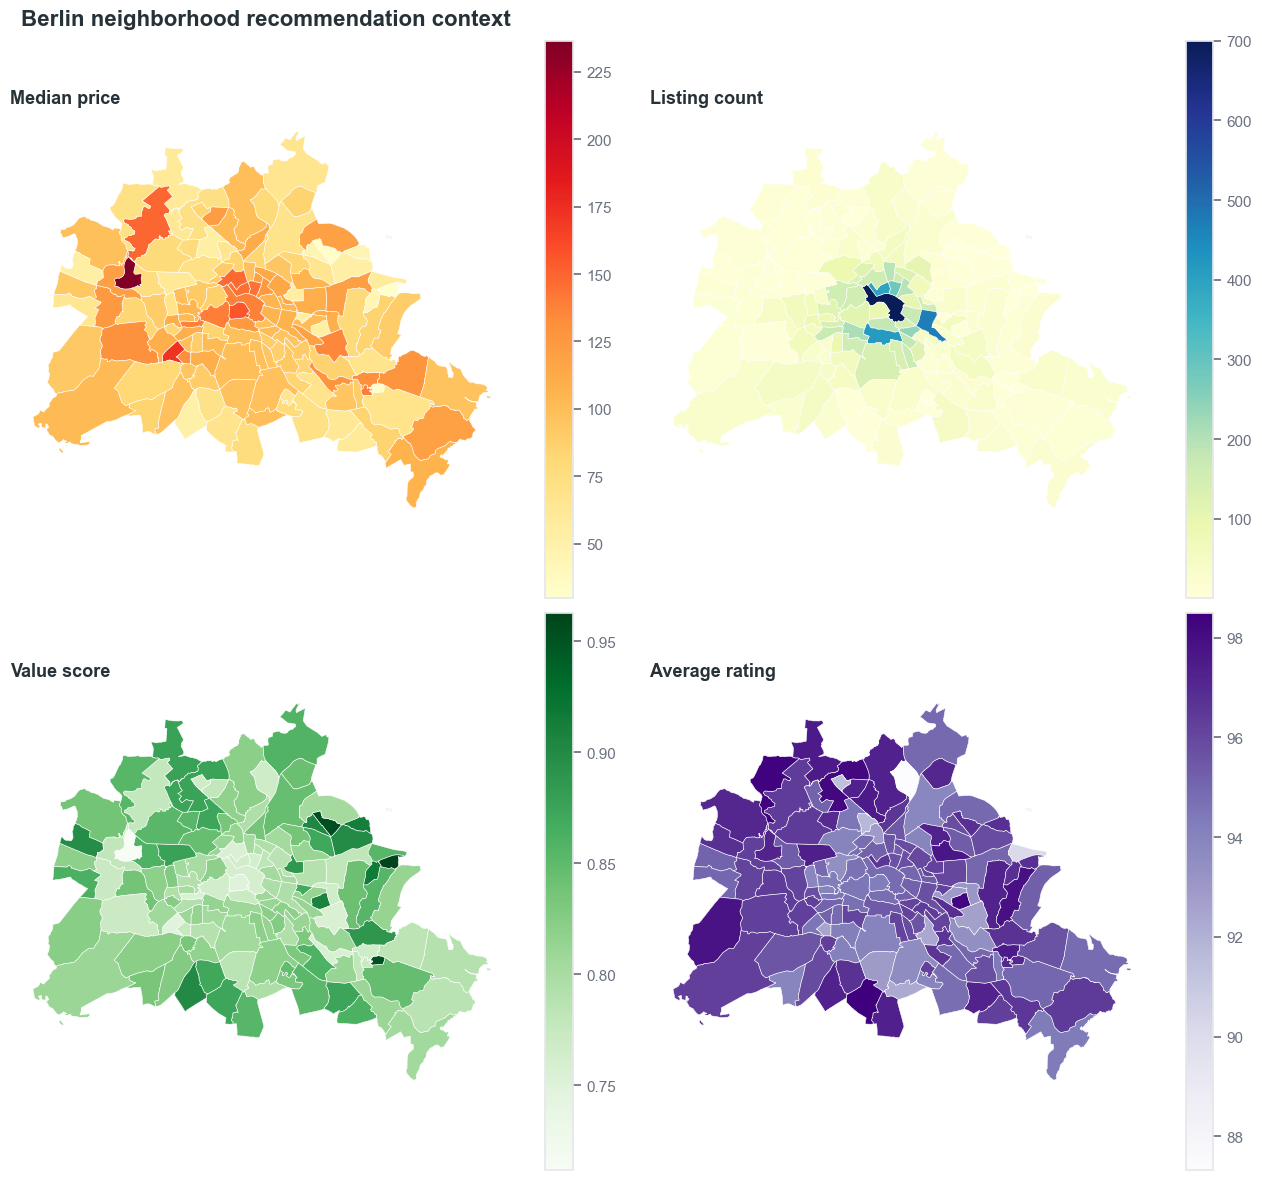

In [38]:
geo = gpd.read_file(GEOJSON_PATH)
geo.columns = [
    normalize_col_name(col)
    for col in geo.columns
]

possible_keys = [
    col for col in geo.columns
    if "neighbour" in col
    or "neighborhood" in col
    or col == "name"
]

listing_neighborhoods = set(
    neighborhood_summary["neighbourhood_cleansed"]
    .astype(str)
    .str.lower()
)

join_key = None
best_overlap = 0

for key in possible_keys:
    overlap = (
        geo[key]
        .astype(str)
        .str.lower()
        .isin(listing_neighborhoods)
        .sum()
    )

    if overlap > best_overlap:
        best_overlap = overlap
        join_key = key

if join_key is None or best_overlap == 0:
    raise ValueError(
        "No matching neighborhood key was found between the GeoJSON file and the Airbnb neighborhood summary."
    )

geo_join = geo.merge(
    neighborhood_summary,
    left_on=geo[join_key].astype(str).str.lower(),
    right_on=neighborhood_summary["neighbourhood_cleansed"].astype(str).str.lower(),
    how="left",
)

plot_specs = [
    ("median_price", "Median price", "YlOrRd"),
    ("listing_count", "Listing count", "YlGnBu"),
    ("median_value_score", "Value score", "Greens"),
    ("avg_rating", "Average rating", "Purples"),
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 12),
)

for ax, (column, title, cmap) in zip(axes.ravel(), plot_specs):
    geo_join.plot(
        column=column,
        ax=ax,
        cmap=cmap,
        legend=True,
        missing_kwds={
            "color": "#F3F4F6",
        },
        edgecolor="white",
        linewidth=0.4,
    )

    ax.set_axis_off()
    ax.set_title(
        title,
        loc="left",
        fontsize=13,
        fontweight="bold",
        color=PALETTE["ink"],
    )

plt.suptitle(
    "Berlin neighborhood recommendation context",
    x=0.02,
    ha="left",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["ink"],
)

plt.tight_layout()
save_fig("neighborhood_choropleth_summary.png")
plt.show()

> Interpretation
> * The choropleth maps translate listing-level signals into neighborhood-level context, making spatial patterns easier to compare across Berlin.
> * Price, supply density, value score, and rating do not move identically across neighborhoods, which supports using location as a contextual ranking feature rather than a simple centrality rule.
> * For recommendation design, neighborhood context can help balance traveler preferences around budget, quality, local area, and marketplace concentration.

## 8.3 Interactive Listing Map Export

This step creates an interactive Folium map with a sample of Berlin Airbnb listings.

The map is saved as an HTML file so the spatial distribution can be explored outside the notebook. This is useful as a product-oriented output, especially when reviewing listing density, price points, room types, and neighborhood context interactively.

In [39]:
if len(geo_sample) > 0:
    center = [
        geo_sample["latitude"].median(),
        geo_sample["longitude"].median(),
    ]

    fmap = folium.Map(
        location=center,
        zoom_start=11,
        tiles="cartodbpositron",
    )

    folium_sample = geo_sample.sample(
        min(len(geo_sample), 1500),
        random_state=SEED,
    )

    for _, row in folium_sample.iterrows():
        folium.CircleMarker(
            location=[
                row["latitude"],
                row["longitude"],
            ],
            radius=2,
            color="#4C78A8",
            fill=True,
            fill_opacity=0.35,
            popup=(
                f"€{row['price']:.0f} | "
                f"{row['room_type']} | "
                f"{row['neighbourhood_cleansed']}"
            ),
        ).add_to(fmap)

    folium_path = OUTPUT_DIR / "berlin_listing_density_map.html"
    fmap.save(folium_path)

    display(
        Markdown(
            f"Interactive map saved to **{folium_path}**."
        )
    )

Interactive map saved to **outputs\berlin_listing_density_map.html**.

> Interpretation
> * The interactive map provides a lightweight product-style output for exploring individual listings by location, price, room type, and neighborhood.
> * Because the map uses a sample of listings for performance, it should be interpreted as an exploratory spatial tool rather than a complete geographic inventory.
> * The static maps remain the primary analytical visuals, while the Folium export adds an interactive layer for inspection, storytelling, and presentation.

# 9. Content-Based Recommendation System

This section builds a content-based recommendation model to identify similar Airbnb listings using listing attributes, location context, pricing signals, amenities, review information, and descriptive text.

The business question is:

**Can similar listings be identified without relying on user history?**

This approach is useful for product surfaces such as “similar stays” because it can recommend comparable listings based only on item-level information. It is especially relevant when user behavior is sparse, unavailable, or when a traveler is browsing anonymously.

The model combines structured features, categorical variables, and text-based signals into a sparse feature matrix, then uses cosine similarity to retrieve listings with similar profiles.

## 9.1 Content Feature Matrix

This step builds the feature matrix used for content-based recommendations.

The matrix combines three types of listing signals:

- **Text features:** listing name, description, neighborhood overview, amenities, and review summary text.
- **Numeric features:** price, rating, availability, popularity, value, sentiment, centrality, and amenity indicators.
- **Categorical features:** room type, neighborhood, and price segment.

The goal is to represent each listing as a comparable vector so similar listings can be retrieved using cosine distance.

In [40]:
content_df = (
    listings
    .drop_duplicates("listing_id")
    .reset_index(drop=True)
    .copy()
)

content_df["listing_id"] = content_df["listing_id"].astype(str)

content_df["content_text"] = (
    content_df["name"].fillna("")
    + " "
    + content_df["description"].fillna("")
    + " "
    + content_df["neighborhood_overview"].fillna("")
    + " "
    + content_df["amenities_text"].fillna("")
    + " "
    + content_df["review_summary_text"].fillna("")
)

content_df["content_text"] = (
    content_df["content_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

content_numeric_cols = [
    "log_price",
    "review_score",
    "number_of_amenities",
    "is_superhost",
    "availability_rate",
    "popularity_score",
    "value_score",
    "average_sentiment",
    "distance_to_center_km",
    "has_wifi",
    "has_kitchen",
    "has_washer",
    "has_workspace",
    "has_air_conditioning",
]

content_numeric_cols = [
    col for col in content_numeric_cols
    if col in content_df.columns
]

content_categorical_cols = [
    "room_type",
    "neighbourhood_cleansed",
    "price_segment",
]

content_categorical_cols = [
    col for col in content_categorical_cols
    if col in content_df.columns
]

text_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    ngram_range=(1, 2),
    stop_words=custom_stop_words,
)

X_text = text_vectorizer.fit_transform(
    content_df["content_text"].fillna("")
)

numeric_data = (
    content_df[content_numeric_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

X_num = (
    sparse.csr_matrix(
        StandardScaler().fit_transform(numeric_data)
    )
    if content_numeric_cols
    else sparse.csr_matrix((len(content_df), 0))
)

categorical_data = (
    content_df[content_categorical_cols]
    .fillna("Unknown")
    .astype(str)
)

onehot = OneHotEncoder(**OHE_KWARGS)

X_cat = (
    onehot.fit_transform(categorical_data)
    if content_categorical_cols
    else sparse.csr_matrix((len(content_df), 0))
)

TEXT_WEIGHT = 0.65
NUMERIC_WEIGHT = 1.20
CATEGORICAL_WEIGHT = 1.10

X_content = sparse.hstack(
    [
        X_text * TEXT_WEIGHT,
        X_num * NUMERIC_WEIGHT,
        X_cat * CATEGORICAL_WEIGHT,
    ],
    format="csr",
)

content_neighbors = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
)

content_neighbors.fit(X_content)

listing_id_to_idx = pd.Series(
    content_df.index.values,
    index=content_df["listing_id"],
).to_dict()

content_matrix_summary = pd.DataFrame({
    "metric": [
        "listings represented",
        "total content features",
        "text features",
        "numeric features",
        "categorical fields",
    ],
    "value": [
        f"{X_content.shape[0]:,}",
        f"{X_content.shape[1]:,}",
        f"{X_text.shape[1]:,}",
        f"{X_num.shape[1]:,}",
        f"{len(content_categorical_cols):,}",
    ],
})

content_matrix_summary

,metric,value
0,listings represented,"9,094"
1,total content features,"5,160"
2,text features,"5,000"
3,numeric features,14
4,categorical fields,3


> Interpretation
> * The content-based model represents 9,094 listings using 5,160 total features that combine text, numeric, categorical, amenity, location, and review-derived signals.
> * Text features dominate the matrix with 5,000 TF-IDF terms, while numeric and categorical features provide structured constraints for price, quality, availability, location, and listing type.
> * Feature weights are applied to reduce excessive dependence on text similarity and give more influence to structured marketplace signals.
> * Because the matrix combines many engineered proxies, similarity should be interpreted as model-defined listing resemblance rather than a definitive measure of traveler preference.

## 9.2 Similar-Stays Recommendation Example

This step defines a content-based recommendation function and tests it on a high-activity listing.

The goal is to evaluate whether the content model can retrieve listings with similar price, room type, neighborhood context, review quality, amenities, and text-based signals. This is closest to a “similar stays” product surface, where a traveler views one listing and receives comparable alternatives.

In [41]:
def name_family(name):
    text = str(name).lower()
    text = re.sub(r"[^a-z0-9\s|]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    if "numa" in text:
        return "numa"

    if "|" in text:
        return text.split("|")[0].strip()

    tokens = [
        token for token in text.split()
        if token not in {
            "the",
            "a",
            "an",
            "with",
            "in",
            "near",
            "close",
            "to",
            "at",
            "and",
            "for",
            "of",
        }
    ]

    return " ".join(tokens[:2]) if tokens else "unknown"


content_df["name_family"] = content_df["name"].apply(name_family)


def recommend_similar_listings(
    listing_id,
    top_n=10,
    candidate_pool=80,
    max_per_neighbourhood=3,
    max_per_name_family=2,
):
    listing_id = str(listing_id)

    if listing_id not in listing_id_to_idx:
        raise ValueError(
            f"Listing {listing_id} was not found in the content model."
        )

    idx = listing_id_to_idx[listing_id]

    n_neighbors = min(
        candidate_pool + 1,
        len(content_df),
    )

    distances, indices = content_neighbors.kneighbors(
        X_content[idx],
        n_neighbors=n_neighbors,
    )

    candidate_rows = []

    for distance, rec_idx in zip(distances.ravel(), indices.ravel()):
        rec_listing = content_df.iloc[rec_idx]
        rec_listing_id = rec_listing["listing_id"]

        if rec_listing_id == listing_id:
            continue

        candidate_rows.append({
            "listing_id": rec_listing_id,
            "name": rec_listing["name"],
            "neighbourhood": rec_listing["neighbourhood_cleansed"],
            "room_type": rec_listing["room_type"],
            "price": rec_listing["price"],
            "review_score": rec_listing["review_score"],
            "similarity_score": 1 - distance,
            "name_family": rec_listing["name_family"],
        })

    candidates = (
        pd.DataFrame(candidate_rows)
        .sort_values("similarity_score", ascending=False)
        .reset_index(drop=True)
    )

    selected_rows = []
    neighbourhood_counts = Counter()
    name_family_counts = Counter()

    for _, row in candidates.iterrows():
        neighbourhood = row["neighbourhood"]
        name_family_value = row["name_family"]

        if neighbourhood_counts[neighbourhood] >= max_per_neighbourhood:
            continue

        if name_family_counts[name_family_value] >= max_per_name_family:
            continue

        selected_rows.append(row)

        neighbourhood_counts[neighbourhood] += 1
        name_family_counts[name_family_value] += 1

        if len(selected_rows) >= top_n:
            break

    recommendations = (
        pd.DataFrame(selected_rows)
        .reset_index(drop=True)
    )

    return recommendations[
        [
            "listing_id",
            "name",
            "neighbourhood",
            "room_type",
            "price",
            "review_score",
            "similarity_score",
        ]
    ]


example_listing_id = (
    content_df
    .sort_values(
        ["number_of_reviews", "review_score"],
        ascending=False,
    )
    .iloc[0]["listing_id"]
)

content_recommendations_sample = recommend_similar_listings(
    example_listing_id,
    top_n=10,
)

content_recommendations_display = content_recommendations_sample[
    [
        "name",
        "neighbourhood",
        "room_type",
        "price",
        "review_score",
        "similarity_score",
    ]
].copy()

content_recommendations_display["price"] = (
    content_recommendations_display["price"]
    .map(lambda x: f"€{x:,.0f}")
)

content_recommendations_display["review_score"] = (
    content_recommendations_display["review_score"]
    .map(lambda x: f"{x:.1f}")
)

content_recommendations_display["similarity_score"] = (
    content_recommendations_display["similarity_score"]
    .map(lambda x: f"{x:.3f}")
)

content_recommendations_display

,name,neighbourhood,room_type,price,review_score,similarity_score
0,Numa | Large Studio w/ Kitchen in Berlin Mitte,Alexanderplatz,Entire home/apt,€180,95.0,0.953
1,Apartment with 2 open rooms,Alexanderplatz,Entire home/apt,€214,92.2,0.952
2,Numa | Large Studio w/ Kitchenette & Extra Bed,Alexanderplatz,Entire home/apt,€163,95.2,0.907
3,Boxi Studios Berlin,Frankfurter Allee Süd FK,Entire home/apt,€163,90.2,0.847
4,Studio,Südliche Friedrichstadt,Entire home/apt,€156,91.6,0.839
5,Studio for 3 persons,Schillerpromenade,Entire home/apt,€172,89.6,0.831
6,★biggest★WiFi★NETFLIX★wide screen★near subway★,Karl-Marx-Allee-Süd,Entire home/apt,€222,91.8,0.826
7,Luxury residence by P&M in Prenzlauer Berg,Prenzlauer Berg Südwest,Entire home/apt,€163,91.4,0.822
8,Top Spot- Kreuzburg Central,südliche Luisenstadt,Entire home/apt,€221,94.2,0.821
9,Studio,Schillerpromenade,Entire home/apt,€159,87.8,0.808


> Interpretation
> * The content-based recommender retrieves listings with similar stay profiles while applying a lightweight diversity rule to reduce over-concentration from the same neighborhood or branded listing family.
> * The recommendations remain coherent for a “similar stays” experience because they preserve key constraints such as room type, price range, review quality, and listing profile.
> * Compared with a pure nearest-neighbor output, the diversity layer creates a more product-realistic recommendation set by avoiding excessive repetition.
> * This model still captures item-to-item similarity rather than true traveler intent, so it is most useful after a traveler clicks, views, saves, or compares a specific listing.

# 10. Collaborative Filtering Proxy

This section builds a collaborative filtering proxy using reviewer-listing interactions from public Airbnb review data.

The business question is:

**Can observed review behavior provide a useful proxy for user preference?**

The dataset does not include clicks, wishlists, searches, bookings, impressions, or conversion events. Reviews are the closest behavioral signal available: when a reviewer leaves a review for a listing, the notebook treats that event as an implicit interaction.

This assumption is imperfect because reviews happen after stays and only represent guests who chose to leave public feedback. Still, repeated reviewer activity can provide useful co-occurrence structure for a recommendation prototype, especially when combined with content-based and ranking signals later in the notebook.

## 10.1 Reviewer-Listing Interaction Matrix

This step converts public review activity into a sparse reviewer-listing interaction matrix.

To reduce noise, the model keeps only reviewers with at least two observed listing interactions and listings with at least three observed reviewer interactions. This creates a more stable collaborative filtering layer while acknowledging that review behavior is only a proxy for preference.

In [42]:
if {"reviewer_id", "listing_id"}.issubset(reviews.columns):
    interactions = reviews[["reviewer_id", "listing_id"]].dropna().copy()
else:
    interactions = pd.DataFrame(columns=["reviewer_id", "listing_id"])

interactions["reviewer_id"] = interactions["reviewer_id"].astype(str)
interactions["listing_id"] = interactions["listing_id"].astype(str)
interactions = interactions.drop_duplicates()

min_user_interactions = 2
min_listing_interactions = 3

user_counts = interactions["reviewer_id"].value_counts()
item_counts = interactions["listing_id"].value_counts()

interactions_cf = interactions[
    interactions["reviewer_id"].isin(user_counts[user_counts >= min_user_interactions].index)
    & interactions["listing_id"].isin(item_counts[item_counts >= min_listing_interactions].index)
].copy()

cf_ready = (
    interactions_cf["reviewer_id"].nunique() >= 5
    and interactions_cf["listing_id"].nunique() >= 5
)

if cf_ready:
    user_codes, user_uniques = pd.factorize(interactions_cf["reviewer_id"])
    item_codes, item_uniques = pd.factorize(interactions_cf["listing_id"])

    interaction_matrix = sparse.csr_matrix(
        (np.ones(len(interactions_cf)), (user_codes, item_codes)),
        shape=(len(user_uniques), len(item_uniques)),
    )

    n_components = int(min(50, max(2, min(interaction_matrix.shape) - 1)))

    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    user_factors = svd.fit_transform(interaction_matrix)
    item_factors = svd.components_.T

    cf_user_to_idx = {user: idx for idx, user in enumerate(user_uniques.astype(str))}
    cf_item_to_idx = {item: idx for idx, item in enumerate(item_uniques.astype(str))}
    cf_item_ids = np.array(item_uniques.astype(str))

else:
    interaction_matrix = None
    user_factors = None
    item_factors = None
    cf_user_to_idx = {}
    cf_item_to_idx = {}
    cf_item_ids = np.array([])

cf_summary = pd.DataFrame({
    "metric": [
        "raw interactions",
        "filtered interactions",
        "filtered users",
        "filtered listings",
        "cf model ready",
    ],
    "value": [
        len(interactions),
        len(interactions_cf),
        interactions_cf["reviewer_id"].nunique(),
        interactions_cf["listing_id"].nunique(),
        cf_ready,
    ],
})

cf_summary

,metric,value
0,raw interactions,628502
1,filtered interactions,83885
2,filtered users,36309
3,filtered listings,7792
4,cf model ready,True


> Interpretation
> * The raw review data provides 628,502 unique reviewer-listing interactions, but the collaborative filtering layer keeps 83,885 interactions after applying minimum activity thresholds.
> * The filtered matrix includes 36,309 reviewers and 7,792 listings, which is sufficient to create a collaborative filtering proxy using matrix decomposition.
> * This behavioral layer captures co-occurrence patterns from observed reviews, not true preference, booking intent, or conversion behavior.
> * Because the interaction signal is sparse and post-stay, collaborative filtering should complement content-based similarity rather than replace structured listing and location features.

## 10.2 Reviewer Profile Construction

This step defines a collaborative recommendation function using reviewer-listing interaction patterns.

The model recommends listings based on observed co-occurrence behavior from reviewers with multiple reviews. When the reviewer is not available in the collaborative filtering matrix, the function falls back to high-quality, popular, and value-oriented listings from the cleaned content base.

In [43]:
def build_reviewer_profile(reviewer_id):
    reviewer_id = str(reviewer_id)

    seen_listing_ids = (
        interactions_cf.loc[
            interactions_cf["reviewer_id"].eq(reviewer_id),
            "listing_id",
        ]
        .astype(str)
        .unique()
    )

    seen_listings = content_df[
        content_df["listing_id"].isin(seen_listing_ids)
    ].copy()

    if seen_listings.empty:
        return None

    room_type_mode = seen_listings["room_type"].mode().iloc[0]
    room_type_share = seen_listings["room_type"].eq(room_type_mode).mean()

    return {
        "median_price": seen_listings["price"].median(),
        "preferred_room_type": room_type_mode,
        "room_type_share": room_type_share,
        "median_rating": seen_listings["review_score"].median(),
        "seen_clean_listings": len(seen_listings),
    }

> Interpretation
> * The reviewer profile creates a lightweight behavioral context from listings previously reviewed by the same user.
> * Price range and room type are used as practical preference proxies, not as confirmed traveler intent.
> * This profile helps reduce noisy collaborative recommendations by aligning results with the reviewer’s observed stay pattern.

## 10.3 Example Reviewer Selection

This step selects a representative reviewer for the collaborative filtering example.

Instead of simply choosing the most frequent reviewer, the notebook looks for a reviewer with enough cleaned listing history and a reasonably consistent room type pattern. This makes the example output easier to interpret.

In [44]:
def choose_example_reviewer(min_seen_clean_listings=3):
    reviewer_counts = interactions_cf["reviewer_id"].value_counts()

    for reviewer_id in reviewer_counts.index[:500]:
        profile = build_reviewer_profile(reviewer_id)

        if profile is None:
            continue

        if (
            profile["seen_clean_listings"] >= min_seen_clean_listings
            and profile["room_type_share"] >= 0.70
        ):
            return reviewer_id

    return reviewer_counts.index[0]


example_reviewer_id = (
    choose_example_reviewer()
    if cf_ready
    else interactions["reviewer_id"].value_counts().index[0]
)

> Interpretation
> * The selected reviewer has enough observed history to support a more coherent collaborative filtering example.
> * This selection is used only for demonstration; it does not imply that this reviewer represents the full traveler population.
> * Choosing a stable example helps the notebook show collaborative filtering behavior without making the output look unnecessarily random.

## 10.4 Behavior-Based Recommendation Function

This step defines the behavior-based recommendation function.

The function uses collaborative filtering to generate candidate listings, then applies a lightweight profile-aware reranking layer based on the reviewer’s observed room type and price range.

In [45]:
def recommend_from_user_behavior(
    reviewer_id,
    top_n=6,
    candidate_pool=200,
    max_per_neighbourhood=2,
):
    reviewer_id = str(reviewer_id)

    if not cf_ready or reviewer_id not in cf_user_to_idx:
        fallback = (
            content_df
            .sort_values(
                ["popularity_score", "review_score", "value_score"],
                ascending=False,
            )
            .head(top_n)
            .copy()
        )

        fallback["behavior_rank_score"] = minmax(
            fallback["popularity_score"]
        )

        return (
            fallback[
                [
                    "listing_id",
                    "name",
                    "neighbourhood_cleansed",
                    "room_type",
                    "price",
                    "review_score",
                    "behavior_rank_score",
                ]
            ]
            .rename(
                columns={
                    "neighbourhood_cleansed": "neighbourhood",
                    "review_score": "rating",
                }
            )
            .reset_index(drop=True)
        )

    reviewer_profile = build_reviewer_profile(reviewer_id)

    user_idx = cf_user_to_idx[reviewer_id]
    scores = user_factors[user_idx] @ item_factors.T

    seen_items = set(
        interactions_cf.loc[
            interactions_cf["reviewer_id"].eq(reviewer_id),
            "listing_id",
        ].astype(str)
    )

    recs = pd.DataFrame({
        "listing_id": cf_item_ids,
        "collaborative_score_raw": scores,
    })

    recs = recs[
        ~recs["listing_id"].isin(seen_items)
    ].copy()

    recs["collaborative_score"] = minmax(
        recs["collaborative_score_raw"]
    )

    recs = (
        recs
        .sort_values("collaborative_score", ascending=False)
        .head(candidate_pool)
        .merge(
            content_df,
            on="listing_id",
            how="inner",
        )
    )

    if reviewer_profile:
        median_price = reviewer_profile["median_price"]
        preferred_room_type = reviewer_profile["preferred_room_type"]

        recs = recs[
            recs["room_type"].eq(preferred_room_type)
            & recs["price"].between(
                median_price * 0.60,
                median_price * 1.60,
            )
        ].copy()

        recs["price_fit_score"] = 1 - minmax(
            abs(recs["price"] - median_price)
        )

        recs["rating_fit_score"] = minmax(
            recs["review_score"]
        )

        recs["behavior_rank_score"] = (
            0.50 * recs["collaborative_score"]
            + 0.30 * recs["price_fit_score"]
            + 0.20 * recs["rating_fit_score"]
        )

    else:
        recs["behavior_rank_score"] = recs["collaborative_score"]

    recs = recs.sort_values(
        "behavior_rank_score",
        ascending=False,
    )

    selected_rows = []
    neighbourhood_counts = Counter()

    for _, row in recs.iterrows():
        neighbourhood = row["neighbourhood_cleansed"]

        if neighbourhood_counts[neighbourhood] >= max_per_neighbourhood:
            continue

        selected_rows.append(row)
        neighbourhood_counts[neighbourhood] += 1

        if len(selected_rows) >= top_n:
            break

    recommendations = (
        pd.DataFrame(selected_rows)
        .reset_index(drop=True)
    )

    return (
        recommendations[
            [
                "listing_id",
                "name",
                "neighbourhood_cleansed",
                "room_type",
                "price",
                "review_score",
                "behavior_rank_score",
            ]
        ]
        .rename(
            columns={
                "neighbourhood_cleansed": "neighbourhood",
                "review_score": "rating",
            }
        )
        .reset_index(drop=True)
    )

> Interpretation
> * The recommender first uses collaborative filtering to generate candidates, then reranks them using profile-aware constraints.
> * Price fit, room type consistency, rating, and neighborhood diversity make the output more product-realistic than pure collaborative filtering.
> * The function returns **listing_id** internally so later evaluation, auditing, and exports can merge recommendation results safely.

## 10.5 Behavior-Based Recommendation Example

This step displays a compact behavior-based recommendation example for the selected reviewer.

The table hides technical identifiers for readability, while the underlying recommendation output keeps **listing_id** available for evaluation and downstream use.

In [46]:
collab_recommendations_sample = recommend_from_user_behavior(
    example_reviewer_id,
    top_n=6,
)

collab_recommendations_display = collab_recommendations_sample[
    [
        "name",
        "neighbourhood",
        "room_type",
        "price",
        "rating",
        "behavior_rank_score",
    ]
].copy()

collab_recommendations_display["price"] = (
    collab_recommendations_display["price"]
    .map(lambda x: f"€{x:,.0f}")
)

collab_recommendations_display["rating"] = (
    collab_recommendations_display["rating"]
    .map(lambda x: f"{x:.1f}")
)

collab_recommendations_display["behavior_rank_score"] = (
    collab_recommendations_display["behavior_rank_score"]
    .map(lambda x: f"{x:.3f}")
)

collab_recommendations_display

,name,neighbourhood,room_type,price,rating,behavior_rank_score
0,"Central, cosy and airy apartment in Kreuzberg",Tempelhofer Vorstadt,Entire home/apt,€89,97.6,0.722
1,Cosy Apartment Prenzlauer Berg,Prenzlauer Berg Süd,Entire home/apt,€96,98.8,0.704
2,Miniloft Altbaucharme in Kreuzberg,südliche Luisenstadt,Entire home/apt,€98,96.6,0.702
3,Wunderschönes Studio mitten in Kreuzberg,südliche Luisenstadt,Entire home/apt,€94,96.6,0.699
4,stylish apartment in Kreuzberg 36,nördliche Luisenstadt,Entire home/apt,€100,97.2,0.696
5,Cosy Appartment in the Courtyard,Tempelhofer Vorstadt,Entire home/apt,€96,95.8,0.695


> Interpretation
> * The behavior-based recommender produces a compact ranking aligned with the reviewer’s observed room type and price range.
> * The final output is intentionally limited because public review behavior is too weak to support a strong standalone personalization claim.
> * The behavior rank score balances collaborative signal, price fit, and rating context, making the result more coherent than raw collaborative filtering.
> * This component should be interpreted as a behavioral proxy for a portfolio prototype, not as a substitute for production data such as clicks, searches, saves, bookings, impressions, or conversions.

# 11. Hybrid Recommendation System

This section combines content similarity, behavioral signals, review quality, popularity, sentiment, and value into a hybrid recommendation ranker.

The business question is:

**Can a hybrid ranking strategy produce more balanced recommendations than a pure similarity-based approach?**

The hybrid model keeps content similarity as the main anchor, adds collaborative filtering when reviewer behavior is available, and protects the recommendation experience with quality, popularity, sentiment, and value signals.

This is not treated as proof of production-level personalization. Instead, the goal is to build an interpretable ranking framework that shows how multiple marketplace signals can be combined into a more product-realistic recommendation system.

## 11.1 Ranking Feature Components

This step prepares the normalized ranking components used by the hybrid recommender.

The goal is to convert listing-level signals such as rating, popularity, sentiment, value, centrality, budget fit, and amenity depth into comparable score components.

In [47]:
ranking_df = content_df.copy()

if "name_family" not in ranking_df.columns:
    ranking_df["name_family"] = ranking_df["name"].apply(name_family)

ranking_df["rating_score_component"] = minmax(ranking_df["review_score"])
ranking_df["popularity_score_component"] = minmax(ranking_df["popularity_score"])
ranking_df["sentiment_score_component"] = minmax(ranking_df["sentiment_score_norm"])
ranking_df["value_score_component"] = minmax(ranking_df["value_score"])
ranking_df["centrality_score_component"] = minmax(ranking_df["centrality_score"])
ranking_df["budget_score_component"] = 1 - minmax(ranking_df["log_price"])
ranking_df["amenity_score_component"] = minmax(ranking_df["number_of_amenities"])

> Interpretation
> * The ranking table converts raw and engineered listing attributes into normalized components that can be combined in a single scoring framework.
> * These components represent different dimensions of recommendation relevance, including quality, popularity, sentiment, value, centrality, affordability, and amenity depth.
> * Because these are engineered signals, they should be interpreted as ranking inputs rather than direct measures of traveler preference or booking probability.

## 11.2 Hybrid Weight Design

This step defines the default hybrid ranking weights and persona-specific weighting strategies.

The default weights prioritize content similarity while adding behavioral, quality, popularity, sentiment, and value signals. Persona weights adjust the ranking logic for different traveler priorities.

In [48]:
DEFAULT_HYBRID_WEIGHTS = {
    "content_similarity": 0.35,
    "collaborative_score": 0.25,
    "rating_score_component": 0.15,
    "popularity_score_component": 0.10,
    "sentiment_score_component": 0.10,
    "value_score_component": 0.05,
}

PERSONA_WEIGHTS = {
    "Budget Traveler": {
        "content_similarity": 0.18,
        "collaborative_score": 0.12,
        "rating_score_component": 0.15,
        "popularity_score_component": 0.08,
        "sentiment_score_component": 0.07,
        "value_score_component": 0.25,
        "budget_score_component": 0.15,
    },
    "Digital Nomad": {
        "content_similarity": 0.22,
        "collaborative_score": 0.12,
        "rating_score_component": 0.17,
        "popularity_score_component": 0.08,
        "sentiment_score_component": 0.11,
        "value_score_component": 0.08,
        "workspace_wifi_score": 0.22,
    },
    "Luxury Traveler": {
        "content_similarity": 0.18,
        "collaborative_score": 0.10,
        "rating_score_component": 0.24,
        "popularity_score_component": 0.08,
        "sentiment_score_component": 0.12,
        "value_score_component": 0.04,
        "amenity_score_component": 0.14,
        "premium_price_score": 0.10,
    },
    "Nightlife Traveler": {
        "content_similarity": 0.20,
        "collaborative_score": 0.12,
        "rating_score_component": 0.12,
        "popularity_score_component": 0.16,
        "sentiment_score_component": 0.08,
        "value_score_component": 0.06,
        "centrality_score_component": 0.18,
        "nightlife_area_score": 0.08,
    },
    "Family Traveler": {
        "content_similarity": 0.18,
        "collaborative_score": 0.08,
        "rating_score_component": 0.22,
        "popularity_score_component": 0.06,
        "sentiment_score_component": 0.10,
        "value_score_component": 0.12,
        "family_amenity_score": 0.24,
    },
}

hybrid_weight_summary = pd.DataFrame({
    "component": list(DEFAULT_HYBRID_WEIGHTS.keys()),
    "weight": list(DEFAULT_HYBRID_WEIGHTS.values()),
})

hybrid_weight_summary

,component,weight
0,content_similarity,0.350
1,collaborative_score,0.250
2,rating_score_component,0.150
3,popularity_score_component,0.100
4,sentiment_score_component,0.100
5,value_score_component,0.050


> Interpretation
> * The default hybrid weights keep content similarity as the main anchor while adding behavioral and marketplace quality signals.
> * The weights are explicit modeling assumptions rather than learned production parameters, which makes the ranking logic easier to inspect and adjust.
> * Persona-specific weights allow the same recommendation framework to adapt to different traveler priorities without changing the underlying data pipeline.

## 11.3 Persona-Specific Ranking Signals

This step creates additional ranking components used by traveler personas.

These signals translate practical traveler needs into interpretable scoring features, such as workspace access for digital nomads, premium positioning for luxury travelers, centrality for nightlife travelers, and family-oriented amenities.

In [49]:
def add_persona_components(df):
    out = df.copy()

    out["workspace_wifi_score"] = minmax(
        ((out.get("has_wifi", 0) + out.get("has_workspace", 0)) / 2)
        + out["rating_score_component"]
    )

    out["premium_price_score"] = minmax(out["log_price"])

    nightlife_neighborhoods = [
        "mitte",
        "kreuzberg",
        "friedrichshain",
        "neukölln",
        "neukoelln",
        "prenzlauer",
    ]

    out["nightlife_area_score"] = (
        out["neighbourhood_cleansed"]
        .str.lower()
        .apply(lambda x: int(any(area in x for area in nightlife_neighborhoods)))
    )

    family_base = (
        out.get("has_kitchen", 0)
        + out.get("has_washer", 0)
        + out["room_type"].str.lower().str.contains("entire").astype(int)
        + out["rating_score_component"]
    )

    out["family_amenity_score"] = minmax(family_base)

    return out


ranking_df = add_persona_components(ranking_df)

> Interpretation
> * Persona-specific features make the hybrid ranker more flexible by aligning recommendations with different traveler needs.
> * These features are engineered proxies, not observed persona labels or validated traveler segments.
> * The goal is to support interpretable recommendation scenarios while keeping the assumptions transparent.

## 11.4 Score Retrieval Helpers

This step defines helper functions that retrieve content-based and collaborative scores for the hybrid ranker.

Content scores come from listing similarity, while collaborative scores come from reviewer-listing co-occurrence patterns when reviewer behavior is available.

In [50]:
def get_content_scores(listing_id=None, max_candidates=1000):
    scores = pd.Series(0.0, index=ranking_df["listing_id"])

    if listing_id is None:
        return scores

    listing_id = str(listing_id)

    if listing_id not in listing_id_to_idx:
        return scores

    idx = listing_id_to_idx[listing_id]
    n_neighbors = min(max_candidates + 1, len(content_df))

    distances, indices = content_neighbors.kneighbors(
        X_content[idx],
        n_neighbors=n_neighbors,
    )

    result = {
        content_df.iloc[rec_idx]["listing_id"]: 1 - distance
        for distance, rec_idx in zip(distances.ravel(), indices.ravel())
        if content_df.iloc[rec_idx]["listing_id"] != listing_id
    }

    scores.loc[list(result.keys())] = list(result.values())

    return scores


def get_collaborative_scores(reviewer_id=None):
    scores = pd.Series(0.0, index=ranking_df["listing_id"])

    if reviewer_id is None or not cf_ready or str(reviewer_id) not in cf_user_to_idx:
        return scores

    user_idx = cf_user_to_idx[str(reviewer_id)]
    raw_scores = user_factors[user_idx] @ item_factors.T

    recs = pd.Series(raw_scores, index=cf_item_ids)

    seen_items = set(
        interactions_cf.loc[
            interactions_cf["reviewer_id"].eq(str(reviewer_id)),
            "listing_id",
        ].astype(str)
    )

    recs = recs.drop(
        labels=[item for item in seen_items if item in recs.index],
        errors="ignore",
    )

    recs_norm = minmax(recs)
    common_ids = scores.index.intersection(recs_norm.index)

    scores.loc[common_ids] = recs_norm.loc[common_ids]

    return scores


def weighted_score(df, weights):
    total = pd.Series(0.0, index=df.index)
    weight_sum = 0

    for column, weight in weights.items():
        if column in df.columns:
            total += df[column].fillna(0) * weight
            weight_sum += weight

    return total / weight_sum if weight_sum > 0 else total

> Interpretation
> * The hybrid ranker retrieves both item similarity and behavioral co-occurrence scores, depending on the available recommendation context.
> * Missing content or behavioral context defaults to zero, allowing the system to remain usable across cold-start and partial-information scenarios.
> * The weighted scoring function keeps the final ranking logic transparent and easy to audit.

## 11.5 Hybrid Recommendation Function

This step defines the main hybrid recommendation function used to combine content similarity, collaborative behavior, listing quality, popularity, sentiment, and value signals.

The function also applies lightweight diversity rules to avoid over-concentrating recommendations in the same neighborhood or branded listing family. This makes the output more realistic for a product recommendation surface.

In [51]:
def hybrid_recommendation(
    listing_id=None,
    reviewer_id=None,
    top_n=8,
    persona=None,
    candidate_pool=500,
    max_per_neighbourhood=3,
    max_per_name_family=2,
):
    base = ranking_df.copy()

    content_scores = get_content_scores(
        listing_id,
        max_candidates=max(1000, top_n * 50),
    )

    collaborative_scores = get_collaborative_scores(
        reviewer_id,
    )

    base["content_similarity"] = (
        base["listing_id"]
        .map(content_scores)
        .fillna(0)
    )

    base["collaborative_score"] = (
        base["listing_id"]
        .map(collaborative_scores)
        .fillna(0)
    )

    if listing_id is not None:
        base = base[
            base["listing_id"].ne(str(listing_id))
        ].copy()

    if reviewer_id is not None and cf_ready:
        seen_items = set(
            interactions_cf.loc[
                interactions_cf["reviewer_id"].eq(str(reviewer_id)),
                "listing_id",
            ].astype(str)
        )

        base = base[
            ~base["listing_id"].isin(seen_items)
        ].copy()

    if listing_id is not None or reviewer_id is not None:
        candidate_mask = (
            (base["content_similarity"] > 0)
            | (base["collaborative_score"] > 0)
        )

        quality_candidates = (
            base
            .sort_values(
                ["rating_score_component", "popularity_score_component"],
                ascending=False,
            )
            .head(max(200, top_n * 20))
            .index
        )

        base = base[
            candidate_mask
            | base.index.isin(quality_candidates)
        ].copy()

    weights = PERSONA_WEIGHTS.get(
        persona,
        DEFAULT_HYBRID_WEIGHTS,
    )

    base["final_score"] = weighted_score(
        base,
        weights,
    )

    ranked_candidates = (
        base
        .sort_values("final_score", ascending=False)
        .head(candidate_pool)
        .copy()
    )

    selected_rows = []
    neighbourhood_counts = Counter()
    name_family_counts = Counter()

    for _, row in ranked_candidates.iterrows():
        neighbourhood = row["neighbourhood_cleansed"]
        name_family_value = row.get("name_family", "unknown")

        if neighbourhood_counts[neighbourhood] >= max_per_neighbourhood:
            continue

        if name_family_counts[name_family_value] >= max_per_name_family:
            continue

        selected_rows.append(row)

        neighbourhood_counts[neighbourhood] += 1
        name_family_counts[name_family_value] += 1

        if len(selected_rows) >= top_n:
            break

    recommendations = (
        pd.DataFrame(selected_rows)
        .reset_index(drop=True)
    )

    return (
        recommendations[
            [
                "listing_id",
                "name",
                "neighbourhood_cleansed",
                "room_type",
                "price",
                "review_score",
                "final_score",
                "content_similarity",
                "collaborative_score",
                "rating_score_component",
                "popularity_score_component",
                "sentiment_score_component",
                "value_score_component",
            ]
        ]
        .rename(
            columns={
                "neighbourhood_cleansed": "neighbourhood",
                "review_score": "rating",
            }
        )
    )

> Interpretation
> * The hybrid recommendation function combines content-based similarity with behavioral, quality, popularity, sentiment, and value signals in a single ranking workflow.
> * Diversity constraints are applied after scoring to reduce repetition across neighborhoods and listing families.
> * The function remains interpretable because each component score is preserved in the full output for auditability.
> * This ranking logic is a transparent product prototype, not a learned production model optimized from real user conversion data.

## 11.6 Hybrid Recommendation Example

This step generates an example hybrid recommendation output using the sample listing and reviewer created earlier in the notebook.

The displayed table is simplified for product readability, while the full recommendation output keeps component-level scores available for inspection.

In [52]:
hybrid_recommendations_sample = hybrid_recommendation(
    listing_id=example_listing_id,
    reviewer_id=example_reviewer_id,
    top_n=8,
)

hybrid_recommendations_display = hybrid_recommendations_sample[
    [
        "name",
        "neighbourhood",
        "room_type",
        "price",
        "rating",
        "final_score",
    ]
].copy()

hybrid_recommendations_display["price"] = (
    hybrid_recommendations_display["price"]
    .map(lambda x: f"€{x:,.0f}")
)

hybrid_recommendations_display["rating"] = (
    hybrid_recommendations_display["rating"]
    .map(lambda x: f"{x:.1f}")
)

hybrid_recommendations_display["final_score"] = (
    hybrid_recommendations_display["final_score"]
    .map(lambda x: f"{x:.3f}")
)

hybrid_recommendations_display

,name,neighbourhood,room_type,price,rating,final_score
0,Studio,Schillerpromenade,Entire home/apt,€159,87.8,0.842
1,Numa | Large Studio w/ Kitchen in Berlin Mitte,Alexanderplatz,Entire home/apt,€180,95.0,0.784
2,Numa | XL Studio with Kitchen & Balcony,Alexanderplatz,Entire home/apt,€194,94.0,0.776
3,Apartment with 2 open rooms,Alexanderplatz,Entire home/apt,€214,92.2,0.760
4,Studio,Südliche Friedrichstadt,Entire home/apt,€156,91.6,0.729
5,Top Spot- Kreuzburg Central,südliche Luisenstadt,Entire home/apt,€221,94.2,0.718
6,Boxi Studios Berlin,Frankfurter Allee Süd FK,Entire home/apt,€163,90.2,0.706
7,Nostalgia - beautiful flat in the heart of Berlin,Frankfurter Allee Nord,Entire home/apt,€95,95.2,0.705


> Interpretation
> * The hybrid recommender produces a compact ranking that balances content similarity, behavioral signal, quality, popularity, sentiment, and value.
> * The output remains anchored in similar stay profiles, but introduces more ranking context than a pure nearest-neighbor content model.
> * Some recommendations still cluster around similar branded or neighborhood patterns, which highlights the tradeoff between similarity and discovery diversity.
> * The hybrid score should be interpreted as an explainable ranking prototype, not as evidence of production-level recommendation performance.

# 12. Traveler Personas

This section adapts the hybrid recommendation framework to different traveler profiles.

The business question is:

**Can the same recommendation system adjust ranking priorities based on different traveler intents?**

Instead of rebuilding the model for each use case, the system changes the ranking weights and feature boosts according to the traveler persona. This creates a more product-like recommendation experience while keeping the logic transparent and auditable.

The personas used in this project are:

- **Budget Traveler:** prioritizes affordability and value.
- **Digital Nomad:** prioritizes workspace, Wi-Fi, reliable reviews, and practical stay quality.
- **Luxury Traveler:** prioritizes high ratings, premium positioning, amenities, and sentiment.
- **Nightlife Traveler:** prioritizes centrality, popular areas, and activity-oriented locations.
- **Family Traveler:** prioritizes entire homes, practical amenities, comfort, and quality.

These personas are not observed user segments from Airbnb behavior data. They are scenario-based ranking profiles created to demonstrate how recommendation logic can adapt to different traveler needs.

## 12.1 Persona-Based Recommendation Interface

This step generates recommendation outputs for each traveler persona using the hybrid ranking framework.

The output is consolidated into a single product-readable table so the recommendations can be compared across personas without overwhelming the notebook with repeated tables.

In [53]:
PERSONA_DESCRIPTIONS = {
    "Budget Traveler": "Affordability and value",
    "Digital Nomad": "Workspace and practical stay quality",
    "Luxury Traveler": "Premium quality and amenities",
    "Nightlife Traveler": "Centrality and activity-oriented areas",
    "Family Traveler": "Comfort and practical amenities",
}


def recommend_for_persona(persona, top_n=5):
    if persona not in PERSONA_WEIGHTS:
        raise ValueError(
            f"Unknown persona. Choose one of: {list(PERSONA_WEIGHTS)}"
        )

    return hybrid_recommendation(
        listing_id=None,
        reviewer_id=None,
        top_n=top_n,
        persona=persona,
    )


persona_tables = {}
persona_summary_rows = []

for persona, focus in PERSONA_DESCRIPTIONS.items():
    persona_recs = recommend_for_persona(
        persona,
        top_n=5,
    )

    persona_tables[persona] = persona_recs.copy()

    top_recommendation = persona_recs.iloc[0]

    persona_summary_rows.append({
        "persona": persona,
        "ranking_focus": focus,
        "top_listing": top_recommendation["name"],
        "neighbourhood": top_recommendation["neighbourhood"],
        "room_type": top_recommendation["room_type"],
        "price": top_recommendation["price"],
        "rating": top_recommendation["rating"],
        "final_score": top_recommendation["final_score"],
    })


persona_summary = pd.DataFrame(persona_summary_rows)

persona_summary["price"] = (
    persona_summary["price"]
    .map(lambda x: f"€{x:,.0f}")
)

persona_summary["rating"] = (
    persona_summary["rating"]
    .map(lambda x: f"{x:.1f}")
)

persona_summary["final_score"] = (
    persona_summary["final_score"]
    .map(lambda x: f"{x:.3f}")
)

persona_summary

,persona,ranking_focus,top_listing,neighbourhood,room_type,price,rating,final_score
0,Budget Traveler,Affordability and value,Schönes Zimmer in Friedrichshain,Frankfurter Allee Süd FK,Private room,€30,100.0,0.647
1,Digital Nomad,Workspace and practical stay quality,Stay with the cool cats in Kreuzberg,Südliche Friedrichstadt,Private room,€77,99.4,0.615
2,Luxury Traveler,Premium quality and amenities,134m² Three-Bedroom Apartment w/ Balcony in Mitte,Brunnenstr. Süd,Entire home/apt,€419,99.6,0.629
3,Nightlife Traveler,Centrality and activity-oriented areas,"Central, cosy and one-of-a-kind",Prenzlauer Berg Südwest,Entire home/apt,€137,97.2,0.601
4,Family Traveler,Comfort and practical amenities,Modernes Apartment in Mehrfamilienhaus mit Garten,Buckow,Entire home/apt,€67,100.0,0.692


> Interpretation
> * Persona-based ranking changes the top recommendation by shifting the importance of affordability, workspace fit, premium quality, centrality, and practical amenities.
> * The table is intentionally limited to the leading recommendation for each persona to keep the output readable and product-oriented.
> * Full recommendation lists are still stored in **persona_tables** for inspection, but the notebook only surfaces the executive summary.
> * These personas are scenario-based ranking profiles, not validated Airbnb customer segments or observed traveler behavior.

# 13. Proxy Evaluation

This section compares recommendation behavior using proxy metrics because the public Airbnb dataset does not include clicks, searches, saves, bookings, impressions, or conversion labels.

The business question is:

**Does the hybrid approach produce a more balanced recommendation set than single-signal methods?**

Since true online performance cannot be measured with this dataset, the evaluation focuses on recommendation behavior rather than predictive accuracy. The goal is to compare whether each method produces different tradeoffs across diversity, price spread, novelty, quality, and similarity.

These metrics should be interpreted as diagnostic indicators, not as proof that one system would outperform another in production.

## 13.1 Proxy Evaluation Metrics

This step defines proxy metrics used to compare recommendation outputs.

The evaluation focuses on behavioral properties of recommendation lists, such as neighborhood diversity, price diversity, novelty, average rating, and similarity when applicable. These metrics help diagnose ranking behavior, but they do not replace real product validation.

In [54]:
def evaluate_recommendations(recs, method_name):
    if recs is None or recs.empty:
        return {
            "method": method_name,
            "neighborhood_diversity": 0,
            "price_diversity": 0,
            "novelty": 0,
            "avg_rating": 0,
            "avg_similarity": np.nan,
        }

    recs = recs.copy()

    if "neighbourhood" not in recs.columns and "neighbourhood_cleansed" in recs.columns:
        recs = recs.rename(columns={"neighbourhood_cleansed": "neighbourhood"})

    recs["listing_id"] = recs["listing_id"].astype(str)

    merged = recs[["listing_id"]].merge(
        ranking_df[
            [
                "listing_id",
                "popularity_score_component",
                "review_score",
                "price",
                "neighbourhood_cleansed",
            ]
        ],
        on="listing_id",
        how="left",
    )

    n_recs = len(recs)

    similarity_col = None

    if "similarity_score" in recs.columns:
        similarity_col = "similarity_score"

    elif "content_similarity" in recs.columns:
        similarity_col = "content_similarity"

    avg_rating = (
        recs["review_score"].mean()
        if "review_score" in recs.columns
        else recs["rating"].mean()
        if "rating" in recs.columns
        else merged["review_score"].mean()
    )

    return {
        "method": method_name,
        "neighborhood_diversity": recs["neighbourhood"].nunique() / max(1, n_recs),
        "price_diversity": recs["price"].std() / max(1, recs["price"].mean()),
        "novelty": 1 - merged["popularity_score_component"].mean(),
        "avg_rating": avg_rating,
        "avg_similarity": recs[similarity_col].mean() if similarity_col else np.nan,
    }

> Interpretation
> * The evaluation metrics compare recommendation list behavior rather than true user outcomes.
> * Neighborhood diversity, price diversity, novelty, rating, and similarity each capture a different ranking tradeoff.
> * Average similarity is only meaningful for content-aware outputs, so it should not be interpreted as a weakness of collaborative recommendations when unavailable.
> * These proxy metrics are useful for diagnostics, but real validation would require user interaction data or online experimentation.

## 13.2 Recommendation Sets for Evaluation

This step generates comparable recommendation outputs from the content-based, collaborative proxy, and hybrid recommenders.

The same representative listing and reviewer context is used across methods so the comparison reflects differences in ranking logic rather than differences in query setup.

In [55]:
content_eval_recs = recommend_similar_listings(
    example_listing_id,
    top_n=20,
)

collab_eval_recs = recommend_from_user_behavior(
    example_reviewer_id,
    top_n=20,
).rename(
    columns={
        "rating": "review_score",
    }
)

hybrid_eval_recs = hybrid_recommendation(
    listing_id=example_listing_id,
    reviewer_id=example_reviewer_id,
    top_n=20,
)

metrics_df = pd.DataFrame([
    evaluate_recommendations(
        content_eval_recs,
        "Content-based",
    ),
    evaluate_recommendations(
        collab_eval_recs,
        "Collaborative proxy",
    ),
    evaluate_recommendations(
        hybrid_eval_recs,
        "Hybrid",
    ),
])

metrics_display = metrics_df.copy()

for col in [
    "neighborhood_diversity",
    "price_diversity",
    "novelty",
    "avg_similarity",
]:
    metrics_display[col] = (
        metrics_display[col]
        .map(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")
    )

metrics_display["avg_rating"] = (
    metrics_display["avg_rating"]
    .map(lambda x: f"{x:.1f}")
)

metrics_display

,method,neighborhood_diversity,price_diversity,novelty,avg_rating,avg_similarity
0,Content-based,0.750,0.167,0.313,92.7,0.825
1,Collaborative proxy,0.750,0.068,0.319,96.6,N/A
2,Hybrid,0.600,0.225,0.286,93.2,0.805


> Interpretation
> * The three recommendation sets are generated from the same representative listing and reviewer context, making the comparison directionally useful.
> * Content-based recommendations preserve strong item similarity, with the highest average similarity score among methods where this metric applies.
> * The collaborative proxy produces the highest average rating and similar neighborhood diversity, but average similarity is not applicable because this method is not based on content distance.
> * The hybrid recommender balances similarity, price variation, quality, and behavioral context, but it should still be interpreted as a proxy evaluation rather than evidence of production performance.

# 14. Business Insights

This section connects the analysis back to Airbnb discovery, recommendation design, and marketplace strategy.

The goal is not to repeat every result from the notebook, but to summarize the strongest signals that matter for a recommendation-oriented product experience.

## 14.1 Key Findings

### 1. Location is a core recommendation context

Berlin’s Airbnb marketplace shows clear geographic variation in supply density, pricing, value signals, and review activity.

This means location should not be treated only as a coordinate input. Neighborhood context can help the recommender balance traveler preferences around budget, centrality, local identity, and availability.

### 2. Price and value need to be handled separately

The analysis shows that expensive neighborhoods and value-oriented neighborhoods are not the same thing.

This supports separating price signals from value signals in the ranking logic. A budget traveler may need affordability and strong review quality, while a premium traveler may respond better to high ratings, amenities, and stronger listing positioning.

### 3. Amenities help explain product fit

Amenities such as washer, kitchen, workspace, air conditioning, and Wi-Fi provide useful signals for matching listings to traveler needs.

However, amenities should be treated as preference-matching features, not as direct proof of listing quality. Their role is strongest when connected to traveler personas such as digital nomads, families, budget travelers, or comfort-oriented guests.

### 4. Guest reviews add useful context beyond structured fields

Review text helps capture practical stay signals such as cleanliness, comfort, location, helpfulness, and quietness.

The sentiment and semantic layers are useful as supporting context, but they should not dominate the ranking system because the reviews are multilingual and the sentiment method is a lightweight proxy.

### 5. Review behavior can support collaborative filtering, but only as a proxy

Reviewer-listing interactions create a usable behavioral layer for a portfolio recommendation prototype.

Still, reviews are post-stay signals. They do not represent clicks, searches, saves, impressions, bookings, or conversion intent. For that reason, collaborative filtering should complement content-based similarity rather than replace it.

### 6. Hybrid ranking creates a more flexible recommendation framework

The hybrid recommender combines content similarity, behavioral co-occurrence, rating quality, popularity, sentiment, and value.

This makes the system more flexible than a pure content-based model because it can adapt to different traveler contexts and ranking goals. The hybrid system should be interpreted as an explainable recommendation prototype, not as proof of production-level performance.

## 14.2 Product Implications

The recommendation system should support different discovery modes instead of relying on a single ranking logic.

A traveler looking for budget-friendly stays should not receive the same ranking priorities as a traveler looking for premium comfort, nightlife access, family practicality, or remote-work readiness.

The strongest product direction is therefore a hybrid ranking system that can:

- keep similar listings relevant;
- avoid excessive repetition;
- incorporate location and neighborhood context;
- use reviews as supporting guest-experience signals;
- adapt weights based on traveler intent;
- preserve quality and value guardrails.


## 14.3 Methodological Limitations

This project uses public Airbnb data, which means several important production signals are unavailable.

The dataset does not include:

- searches;
- clicks;
- saves;
- impressions;
- bookings;
- cancellations;
- conversion rates;
- user sessions;
- real traveler profiles.

As a result, the recommendation system is evaluated with proxy metrics and should be interpreted as a transparent portfolio prototype rather than a production-validated recommender.

The main analytical value of the project is the design of an interpretable recommendation framework that combines marketplace signals, geospatial context, review language, behavioral proxies, and traveler-persona ranking logic.



## 14.4 Final Business Takeaway

Airbnb discovery in Berlin benefits from a multi-signal recommendation approach.

Listing similarity is useful, but it is not enough by itself. Stronger recommendation logic comes from combining structured listing attributes, neighborhood context, price and value signals, guest review language, behavioral proxies, and traveler-specific ranking priorities.

Overall, the project shows how a hybrid recommendation framework can make accommodation discovery more flexible, explainable, and product-oriented, while remaining honest about the limits of public marketplace data.

# 15. Final Conclusion

This project answers the central question:

**How can a hybrid recommendation system personalize Airbnb listing discovery in Berlin using listing features, geospatial context, and review behavior?**

A hybrid recommendation system can personalize discovery by combining complementary marketplace signals instead of relying on a single ranking logic.

Content-based similarity captures what each listing offers through room type, price range, amenities, neighborhood, descriptive text, and quality-related attributes. This makes it useful for “similar stays” recommendations, especially when user history is unavailable.

Geospatial analysis adds location-aware context by showing how supply density, pricing, value signals, and review activity vary across Berlin neighborhoods. This helps the system avoid treating centrality as universally better and instead use location as a flexible ranking context.

Review text adds the guest voice to the recommendation framework. Sentiment, positive review terms, and semantic review vectors provide additional context beyond structured ratings, although these signals remain imperfect because public reviews are multilingual and unevenly distributed across listings.

Reviewer-listing interactions provide a behavioral layer through collaborative filtering, but only as a proxy. Since the dataset does not include clicks, searches, saves, impressions, bookings, or conversions, review behavior should be interpreted as observed post-stay activity rather than direct traveler intent.

The hybrid ranker brings these signals together into an interpretable product framework. It can balance similarity, behavior, quality, popularity, sentiment, value, and persona-specific priorities, making the recommendation experience more flexible than a generic one-size-fits-all ranking.

The main limitation is that this project uses public Airbnb data rather than production interaction logs. As a result, the system should be understood as a transparent portfolio prototype, not as a production-validated recommender.

A natural next step would be to train and evaluate the ranking logic using real user interaction data, including searches, clicks, saves, bookings, impressions, and conversions. In a real product environment, the final validation would require offline ranking evaluation followed by controlled A/B testing.

Overall, the project shows how structured listing attributes, neighborhood context, guest review language, behavioral proxies, and traveler-persona ranking logic can be combined to make Airbnb discovery more personalized, explainable, and product-oriented.